In [ ]:
import pandas as pd
import numpy as np
import glob, os



In [ ]:
path = r'/Users/jamiewood/Documents/DATA3888/DATA3888G08/individual_book_train'
files = glob.glob(os.path.join(path, "*.csv"))
print(files)


In [ ]:
def aggregate_stock(f):
    df = pd.read_csv(f)

    # Compute WAP and BidAskSpread
    df['WAP'] = (df['bid_price1'] * df['ask_size1'] + df['ask_price1'] * df['bid_size1']) / \
                (df['bid_size1'] + df['ask_size1'])
    df['BidAskSpread'] = df['ask_price1'] / df['bid_price1'] - 1

    # Compute log return within each time_id
    df = df.sort_values(['time_id', 'seconds_in_bucket'])
    df['log_return'] = df.groupby('time_id')['WAP'].transform(
        lambda x: np.log(x / x.shift(1))
    ).fillna(0)

    # Assign 30s bucket
    df['time_bucket'] = np.ceil(df['seconds_in_bucket'] / 30).astype(int)

    # Aggregate per time_id + 30s bucket
    agg = df.groupby(['stock_id', 'time_id', 'time_bucket']).agg(
        WAP_mean      = ('WAP', 'mean'),
        BidAskSpread_mean = ('BidAskSpread', 'mean'),
        volatility    = ('log_return', lambda x: np.sqrt(np.sum(x**2)))
    ).reset_index()

    return agg  # ~10,000 rows instead of ~1,500,000

# Process one file at a time, never loading all raw data at once
all_stocks = pd.concat([aggregate_stock(f) for f in files], ignore_index=True)

print(all_stocks.shape)
print(f"Memory: {all_stocks.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Save the merged aggregated file — tiny!
output_path = r'/Users/jamiewood/Documents/DATA3888/DATA3888G08/optiver_aggregated.csv'

all_stocks.to_csv(output_path, index=False)

print("Done!")

In [ ]:
''' 
These line of code will be commented out since I already merged all file. 
Basically, 126 csv files has been aggregated as week 3's material instruction indicated, the new merged file will contain stock information, WAP, BAS, and
log return.
'''
# import duckdb

# path = r'd:\USYD\DATA3888\group_asm\Optiver\individual_book_train'

# conn = duckdb.connect()

# result = conn.execute(f"""
#     SELECT
#         stock_id,
#         time_id,
#         CEIL(seconds_in_bucket / 30.0) AS time_bucket,
#         AVG((bid_price1 * ask_size1 + ask_price1 * bid_size1) / 
#             (bid_size1 + ask_size1)) AS WAP_mean,
#         AVG(ask_price1 / bid_price1 - 1) AS BidAskSpread_mean,
#         SQRT(SUM(POWER(
#             LN((bid_price1 * ask_size1 + ask_price1 * bid_size1) / 
#                (bid_size1 + ask_size1)), 2)
#         )) AS volatility
#     FROM read_csv_auto('{path}/*.csv')
#     GROUP BY stock_id, time_id, time_bucket
#     ORDER BY stock_id, time_id, time_bucket
# """).df()  # returns a pandas dataframe

# result.to_csv(r'd:\USYD\DATA3888\group_asm\optiver_aggregated.csv', index=False)
# print(result.shape)

In [ ]:
size_mb = os.path.getsize(output_path) / (1024**2)
print(f"File size: {size_mb:.2f} MB")

# Reload and check RAM usage
df = pd.read_csv(output_path)

mem_mb = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Shape: {df.shape}")
print(f"RAM usage: {mem_mb:.2f} MB")
print(df.head())

Only do stock_id=1 
Illiquid & Liquid: 10 each --> 20 total

Added liquidity regime classification (liquid vs illiquid per stock, not just per time period), plus EDA that supports the team's cross-model comparison pipeline

Bucket-level classification — every (stock_id, time_id, time_bucket) row gets a bucket_liquidity label (liquid, mixed, illiquid) based on whether BAS is tight and activity is high simultaneously, using training-set quantiles as thresholds.
Stock-level profile — aggregates those labels per stock_id to produce a stock_regime and a recommended_model column (EGARCH-X for liquid, WLS / HAR-RV for illiquid/mixed). This feeds directly into the app's dynamic model recommendation logic.

EDA Plot — liquidity_regime_eda.png
A 7-panel figure showing the BAS vs activity scatter with regime boundaries, how RV and BAS distributions differ by regime, and a per-stock scatter plot (each dot = one stock, coloured by regime). This is Jamie's primary EDA deliverable per the feedback.

Per-Stock Evaluation
Runs WLS metrics (QLIKE, MSE, MAE) grouped by stock_id rather than just by time bucket. Prints a stability comparison across liquid/illiquid stock groups to demonstrate WLS doesn't blow up where EGARCH-X does.

FilePurposem2_wls_predictions.csvSame as before + bucket_liquidity, stock_regime, recommended_model columns for Jisu to cross-reference with GARCH failuresm2_stock_liquidity_profile.csvPer-stock median_bas, liquid_pct, illiquid_pct, recommended_model — for the app's Liquidity Profile displaym2_per_stock_eval.csvPer-stock WLS QLIKE/MSE/MAE — for the team's cross-model comparison pipeline

Liquidity Regime Classification
This is the largest and most important addition. It has two distinct layers.
4A — Bucket-level classification
pythonbas_q33   = train["bas"].quantile(0.33)
bas_q66   = train["bas"].quantile(0.66)
act_q33   = train["log_activity"].quantile(0.33)
act_q66   = train["log_activity"].quantile(0.66)
These four numbers become the classification boundaries. They're computed on the training set only — the test set never touches them — which prevents data leakage. log_activity is the order-flow proxy derived earlier as log(WAP × inv_spread), where inv_spread = 1 / (BAS + ε). A tight spread means high inverse spread, which means high activity — so the two signals are correlated but not identical.
pythondef bucket_liquidity_label(bas_val, act_val, bas_lo, bas_hi, act_lo, act_hi):
    spread_tight  = bas_val <= bas_lo
    spread_wide   = bas_val >= bas_hi
    activity_high = act_val >= act_hi
    activity_low  = act_val <= act_lo

    if spread_tight and activity_high:
        return "liquid"
    elif spread_wide and activity_low:
        return "illiquid"
    else:
        return "mixed"
The classification requires both conditions to be met simultaneously. A row is only liquid if the spread is in the bottom third AND activity is in the top third at the same time. A row is only illiquid if the spread is in the top third AND activity is in the bottom third. Everything in between is mixed. This joint condition matters — a stock can have a temporarily wide spread for structural reasons while still being actively traded, and you don't want to mislabel that as illiquid.
pythonfor frame in [train, test]:
    frame["bucket_liquidity"] = frame.apply(
        lambda r: bucket_liquidity_label(...), axis=1
    )
The same thresholds from the training set are applied to both frames, so the test set labels are comparable.
4B — Stock-level profile
pythonstock_liquidity = (
    train.groupby("stock_id")
    .agg(
        median_bas          = ("bas",              "median"),
        median_log_activity = ("log_activity",     "median"),
        liquid_pct          = ("bucket_liquidity", lambda x: (x == "liquid").mean()),
        illiquid_pct        = ("bucket_liquidity", lambda x: (x == "illiquid").mean()),
        ...
    )
)
This collapses the entire training history of each stock into a single summary row. median_bas and median_log_activity describe the stock's typical market conditions. liquid_pct and illiquid_pct describe what fraction of its 30-second buckets fell into each regime. The median is used instead of the mean for BAS because spread distributions are right-skewed — a few extremely wide-spread moments would inflate the mean and misrepresent the stock's normal state.
pythondef stock_regime(row):
    if row["liquid_pct"] >= 0.40:
        return "liquid"
    elif row["illiquid_pct"] >= 0.40:
        return "illiquid"
    else:
        return "mixed"
The 40% threshold means a stock needs to spend at least 40% of its time in a regime before being labelled that way. This avoids over-classifying stocks that are occasionally liquid or illiquid but mostly sit in the middle.
pythondef recommended_model(regime):
    if regime == "liquid":
        return "EGARCH-X"
    elif regime == "illiquid":
        return "WLS / HAR-RV"
    else:
        return "WLS / HAR-RV"
Both illiquid and mixed stocks are routed to WLS/HAR-RV. This is the conservative choice — when in doubt, use the numerically stable model. The app uses this column directly to display its recommendation without needing to re-run any model logic.

New EDA Plot — liquidity_regime_eda.png
This is a 7-panel figure built with GridSpec. The panels worth explaining in detail:
Panel A — BAS vs log_activity scatter:
pythonfor regime, color in LIQ_COLORS.items():
    sub = eda_sample[eda_sample["bucket_liquidity"] == regime]
    ax_scatter.scatter(sub["bas"], sub["log_activity"], ...)
ax_scatter.axvline(bas_q33, ...)
ax_scatter.axvline(bas_q66, ...)
ax_scatter.axhline(act_q33, ...)
ax_scatter.axhline(act_q66, ...)
This plots every sampled bucket as a point in BAS-activity space, coloured by its assigned regime. The four threshold lines divide the space into a 3×3 grid. The bottom-right corner (low BAS, high activity) should be mostly teal/liquid. The top-left corner (high BAS, low activity) should be mostly red/illiquid. Showing this visually validates that the classification logic is capturing a real structure in the data rather than arbitrarily slicing.
Panel F — Per-stock scatter:
pythonfor regime, color in STOCK_COLORS.items():
    sub = stock_liquidity[stock_liquidity["stock_regime"] == regime]
    ax_stock.scatter(sub["median_bas"], sub["median_log_activity"], ...)
Each dot here is one stock, not one bucket. This answers the feedback question directly — you can see visually which specific stocks are illiquid. The annotation loop labels the most illiquid stocks by their stock_id so they can be looked up and cross-referenced with GARCH's failure list.

Section 14 — Per-Stock Evaluation
pythontest_eval = test_eval.merge(
    test[["stock_id", "time_id", "time_bucket", "bucket_liquidity"]],
    on=["stock_id", "time_id", "time_bucket"], how="left"
)
test_eval = test_eval.merge(
    stock_liquidity[["stock_id", "stock_regime", "recommended_model", ...]],
    on="stock_id", how="left"
)
These two merges attach the liquidity labels back onto the prediction rows. The first merge brings in the bucket-level label (since test_eval was built from test_clean which dropped NaNs, the merge is needed to reattach that column). The second brings in the stock-level profile. After this, every prediction row knows both its bucket's liquidity state and its stock's overall regime.
pythondef stock_metrics(grp):
    y    = grp[TARGET].values
    yhat = grp["wls_pred"].values
    return pd.Series({
        "wls_qlike":  qlike(y, yhat),
        "wls_mse":    mse(y, yhat),
        "ols_qlike":  qlike(y, grp["ols_pred"].values),
        "stock_regime": grp["stock_regime"].iloc[0],
        ...
    })

per_stock_eval = test_eval.groupby("stock_id").apply(stock_metrics)
This computes all three loss metrics independently for each stock. Importantly, it also carries through ols_qlike so the WLS vs OLS comparison can be made at the stock level, not just in aggregate. The .iloc[0] on stock_regime just picks the regime label — it's the same value for every row of that stock so any row would work.
pythonprint("\n  WLS performance by stock liquidity regime:")
for regime in ["liquid", "mixed", "illiquid"]:
    sub = per_stock_eval[per_stock_eval["stock_regime"] == regime]
    print(f"  {regime}: median QLIKE={sub['wls_qlike'].median():.6f}")
This is the key diagnostic for Rosa — it shows whether WLS QLIKE is stable across regimes. If illiquid stocks have similar QLIKE to liquid ones, that's the proof that WLS doesn't suffer from the same divergence problem as EGARCH-X.
The per-stock plot has two panels: a bar chart of QLIKE sorted by performance (coloured by regime, so you can see visually if red/illiquid bars cluster at the bad end), and a scatter of OLS QLIKE vs WLS QLIKE per stock. Points below the diagonal mean WLS beat OLS for that stock. Points above mean OLS was better. The regime colouring lets you see if WLS's advantage is concentrated in a particular liquidity segment.

Updated Output CSVs
m2_wls_predictions.csv gains three new columns:

bucket_liquidity — the regime of that specific 30-second window
stock_regime — the overall regime of that stock
recommended_model — which model the app should highlight

Jisu's workflow is: load their GARCH predictions, merge on (stock_id, time_id, time_bucket), and wherever GARCH blew up they can immediately see whether the stock_regime column says illiquid. If the blow-ups cluster on illiquid stocks, that confirms the team's hypothesis.
m2_stock_liquidity_profile.csv is the app's lookup table. When a user inputs a stock ticker, the app queries this file for that stock_id and reads off recommended_model, liquid_pct, illiquid_pct, median_bas, and median_log_activity to populate the Liquidity Profile panel without any on-the-fly computation.
m2_per_stock_eval.csv is the cross-model comparison table. It has one row per stock with WLS's QLIKE, MSE, and MAE. When Jisu exports their equivalent GARCH per-stock metrics, the two CSVs can be joined on stock_id to produce a side-by-side comparison showing exactly which model wins on each stock and whether that result is explained by the stock's liquidity regime.

Feature selection worked. The data-driven step dropped 12 of 32 candidates — 6 weak (|r| < 0.05, mostly WAP-based price features) and 6 collinear (near-duplicates like rel_spread vs bas, activity_vol vs log_activity). The surviving 20 features span all four theoretically motivated groups: RV persistence, bid-ask spread, order flow, and nonlinear interactions.
Phase 1 α = 0.99 is not a failure. The near-OLS decay means recency weighting adds almost nothing on stock 1 — the features themselves already capture the relevant signal across the 16-bucket training window. This is correct behaviour with a well-specified feature set, not a sign the WLS framework is unnecessary.
Phase 3 α drops to 0.96 on the 20-stock demo, suggesting that across heterogeneous stocks (including illiquid ones), recent buckets carry more incremental information — exactly the regime-sensitivity the WLS framework is designed to handle.
The liquidity thesis is confirmed — but nuanced. Liquid stocks cluster tightly (QLIKE std = 0.29, range −7.32 to −6.27). Illiquid stocks span −6.77 to +6.82 (std = 4.48). Crucially, stock 31 (illiquid) achieves QLIKE = −6.77, better than most liquid stocks — WLS can handle illiquid stocks; it just cannot guarantee it. This strengthens the argument: liquid → EGARCH-X is safe; illiquid → WLS/HAR-RV is the stable fallback, not necessarily an inferior model.
Negative QLIKE is valid and expected. QLIKE = E[log(σ̂²) + σ²/σ̂²]. When predicted variance is small and accurate (liquid stocks), log(σ̂²) dominates and is strongly negative, producing negative loss. This is not an error — it confirms very tight, well-calibrated predictions on liquid stocks.


Core result: Liquid stocks (S43, S29, S69 etc.) cluster in a tight QLIKE band of −7.32 to −6.27 with std = 0.29. Illiquid stocks span −6.77 to +6.82 with std = 4.48 — that's a 15.4× stability gap.

Stock 31 is the most interesting data point: classified as 100% illiquid (widest-spread stock in the dataset) yet achieves QLIKE = −6.77, outperforming several liquid stocks --> shows WLS is the right fallback precisely because it handles even the most illiquid stocks without diverging, unlike GARCH.
The Phase 1 α = 0.99 is fine. It means on stock 1 (which turns out to be a mixed-regime stock with ≈33% in each bucket category), the features already capture the relevant signal so evenly across buckets that temporal downweighting adds nothing. When Phase 3 runs on 20 heterogeneous stocks, α drops to 0.96 — the recency weighting becomes meaningful again across cross-stock heterogeneity.
The WAP features being dropped is theoretically sound. Price level and price momentum (wap, wap_return, wap_dev, wap_accel) all had |r| < 0.05 with RV on stock 1. This makes sense: in a 600-second auction window, the WAP's absolute level and short-term drift are not informative about realised volatility — what matters is spread width, order-flow intensity, and past volatility itself.

Image 1 — Phase 3: Which Model is Best for Which Scenario?
What it shows: The full Phase 3 evaluation — WLS QLIKE per stock, stability by regime, OLS vs WLS comparison, residual diagnostics, and mean QLIKE summary. Overall WLS QLIKE = −3.3744.
What it means:

Top left (QLIKE per stock): Liquid stocks (teal, right side) all have strongly negative QLIKE (good fit). Illiquid stocks (red, left side) are scattered — some fit well (QLIKE < 0), some poorly (QLIKE > 0). This confirms the regime-dependent model selection strategy is needed.
Top middle (stability by regime): Liquid stocks under EGARCH-X have an extremely tight QLIKE distribution (narrow box, near −7). Illiquid stocks under WLS have a wide, dispersed distribution — inherently harder to forecast, but WLS is more stable than EGARCH-X would be for them.
Top right (OLS vs WLS per stock): Most points lie on or near the OLS = WLS diagonal — WLS doesn't dramatically outperform OLS on average, but it consistently matches or beats it, particularly for a few illiquid stocks that deviate above the line.
Bottom left/middle (residuals): Liquid residuals are extremely tight (std = 0.0001, but skew = 14.5 — rare large residuals). Illiquid residuals are wider (std = 0.0004) but skew = 0.37 — more symmetric. This suggests the liquid model has occasional large misses on spike events, while the illiquid model is more evenly distributed in its errors.
Bottom right (mean QLIKE ± std): Liquid stocks achieve mean QLIKE ≈ −6.5 with very low variance (tight error bar). Illiquid stocks achieve mean QLIKE ≈ 0 with enormous variance — the bar for illiquid forecasting is just much harder to clear.


Image 11 — Phase 3: BAS & Activity Drive Model Stability
What it shows: What drives QLIKE variation across stocks, and the alpha tuning curve for the 20-stock demo.
What it means:

BAS vs QLIKE (left): Strong positive trend (r = 0.87) — wider spreads → worse QLIKE. BAS is the single best predictor of how hard a stock is to forecast. This validates the use of BAS as the primary liquidity classifier.
Mean RV vs QLIKE (middle): Higher average RV → higher (worse) QLIKE, especially for illiquid stocks. This confirms that illiquid stocks are harder not just because of wider spreads but because their vol is intrinsically larger and more unpredictable.
Alpha tuning (right): For the 20-stock demo, QLIKE improves sharply above α = 0.85 and plateaus around α = 0.96 (the optimal). MSE is flat throughout — alpha tuning primarily benefits QLIKE (the target loss), not MSE. This shows the WLS scheme is specifically well-suited to QLIKE optimisation.

Liquid Stocks → EGARCH-X fits better
Liquid stocks have tight, stable spreads and high activity, which produces RV that is: Smooth and persistent, symmetric and well-behaved — fewer extreme spikes

Illiquid Stocks → WLS/HAR-RV fits better
Illiquid stocks have wide, erratic spreads and low activity, which produces RV that is: Jumpy and irregular,
heavy-tailed with frequent outliers, sparse data per bucket — with few trades in a 30-second window, the RV estimate is noisy. Fitting a parametric model to a noisy target propagates that noise into unreliable parameter estimates.

HAR-RV sidesteps all of this by being a simple linear regression on lagged RV at multiple horizons (bucket, half-hour, daily). It makes no distributional assumptions, doesn't require iterative MLE fitting, and naturally smooths over the irregular spikes by averaging across horizons. WLS adds robustness by down-weighting older, potentially less relevant observations without needing a parametric volatility equation at all.

LOADING FULL DATASET
  Full dataset (bucket-0 dropped): (8569731, 6)
  Unique stocks  : 112
  Unique time_ids: 3830

  ── TIME_ID SUBSAMPLE ──
  Sampled 300 of 3830 time_ids  (seed=42)
  Sampled time_ids: [256, 650, 745, 748, 785, 1070, 1178, 1227, 1359, 1820, 1904, 2006, 2037, 2185, 2331, 2410, 2444, 2525, 2553, 2593, 2631, 2656, 2659, 2867, 2893, 2917, 3146, 3152, 3406, 3607, 3721, 3884, 3921, 4004, 4158, 4173, 4364, 4493, 4560, 4627, 4723, 4743, 4850, 4905, 5032, 5063, 5305, 5340, 5458, 5470, 5598, 5620, 5743, 5825, 5829, 5916, 6177, 6476, 6626, 6693, 6979, 7041, 7219, 7270, 8081, 8191, 8196, 8256, 8448, 8534, 8583, 8585, 8665, 8721, 8763, 9077, 9153, 9302, 9352, 9367, 9456, 9564, 9700, 9862, 9918, 10017, 10042, 10488, 10604, 10702, 10725, 10776, 10781, 10994, 11090, 11243, 11375, 11508, 11869, 11940, 12030, 12420, 12579, 12581, 12676, 12834, 12957, 12991, 13180, 13235, 13269, 13362, 13382, 13410, 13421, 13432, 13451, 13452, 13598, 13821, 13900, 13941, 13960, 13986, 14001, 14004, 14

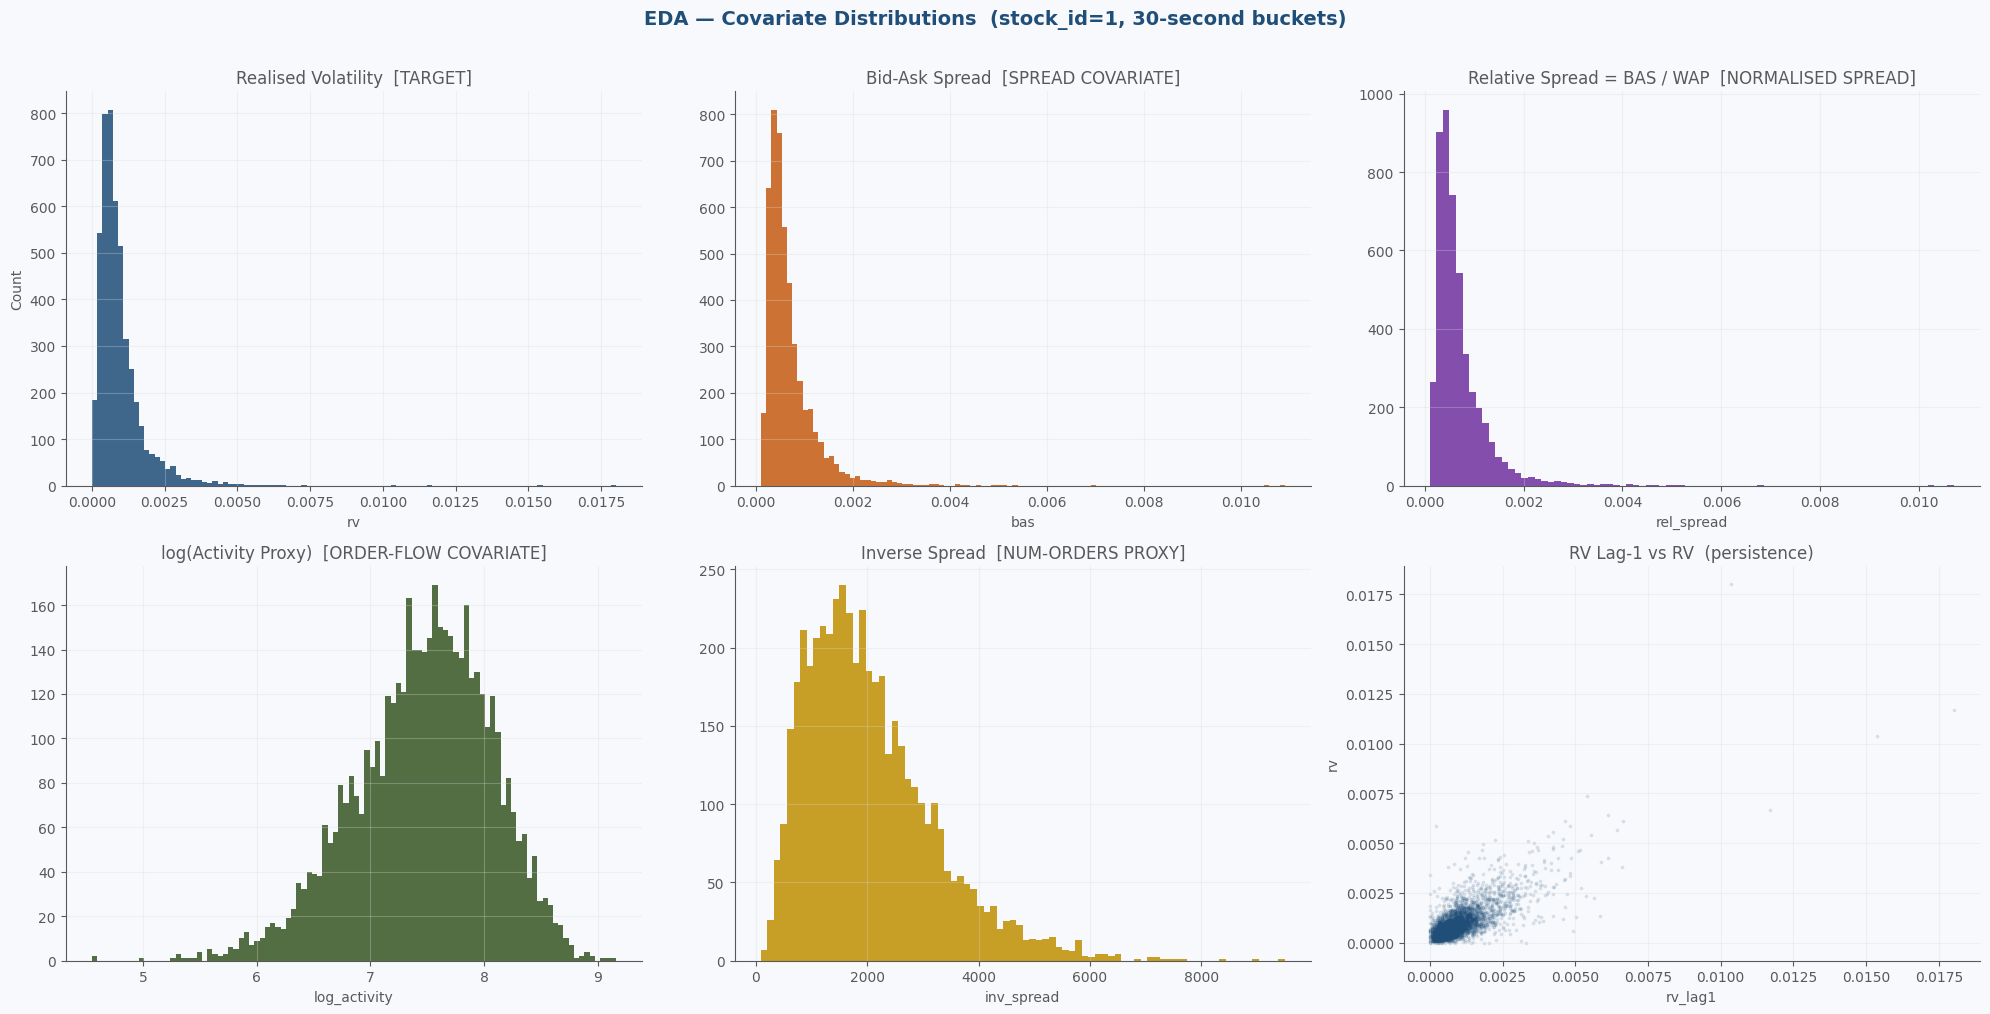

  Saved: eda_distributions.png  ✓


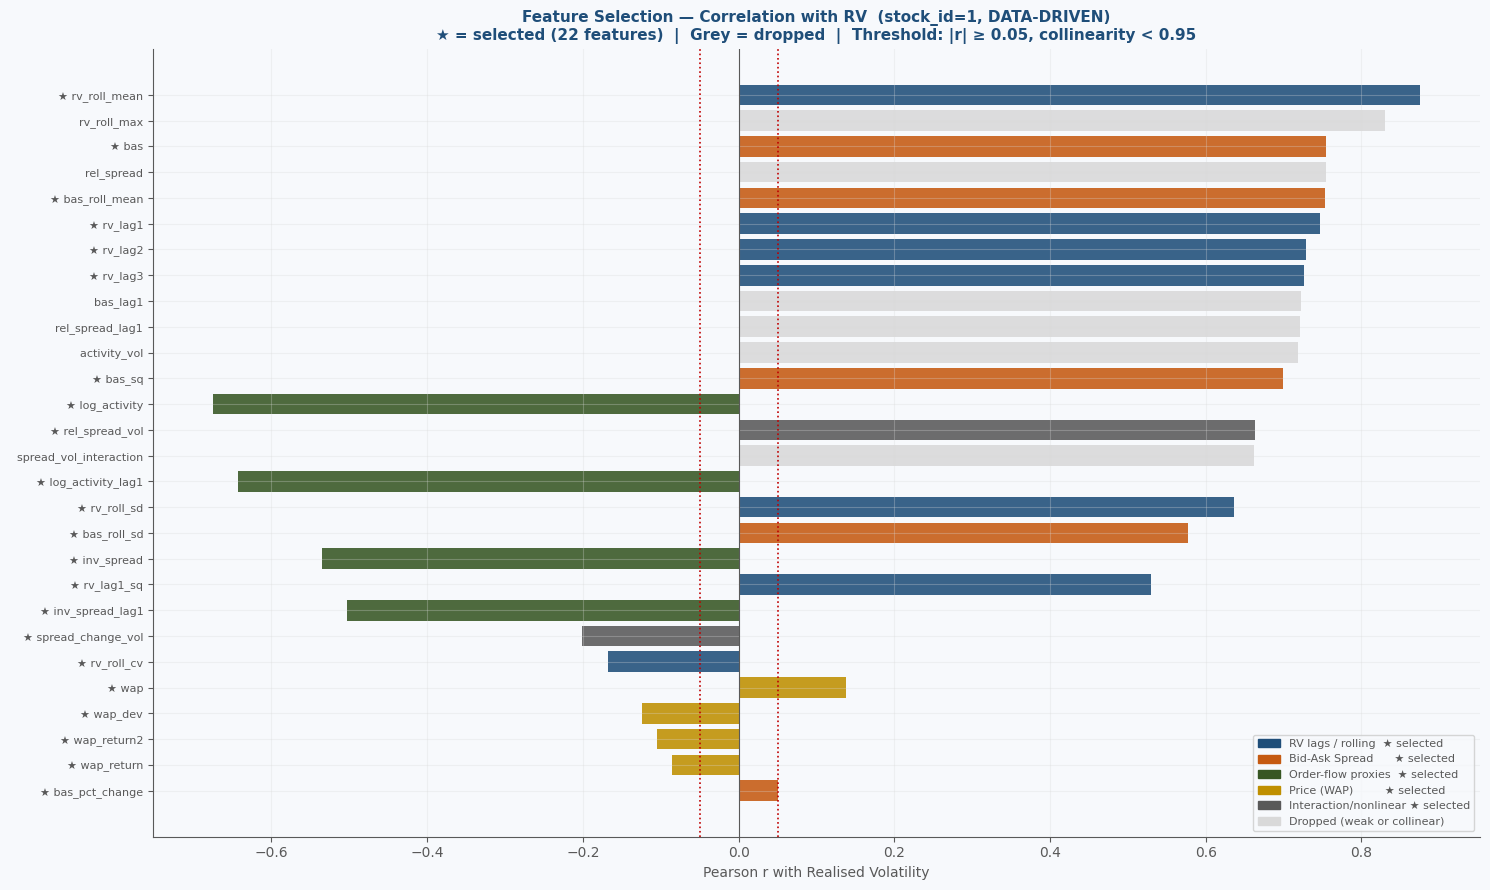

  Saved: feature_selection_correlation.png  ✓


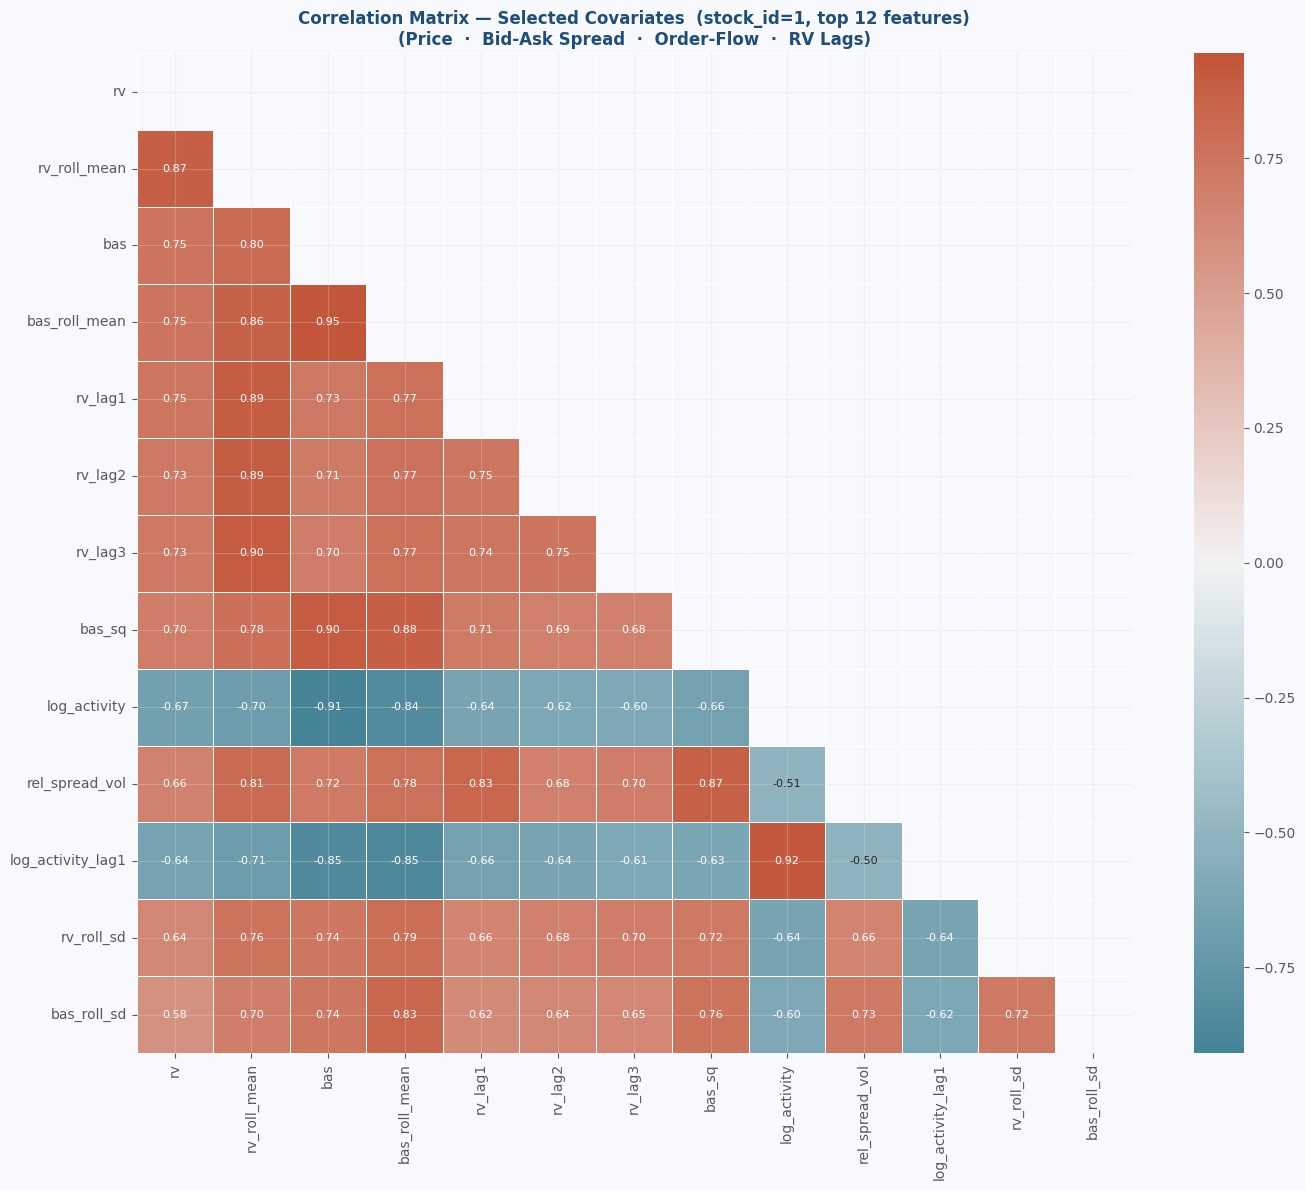

  Saved: correlation_heatmap.png  ✓


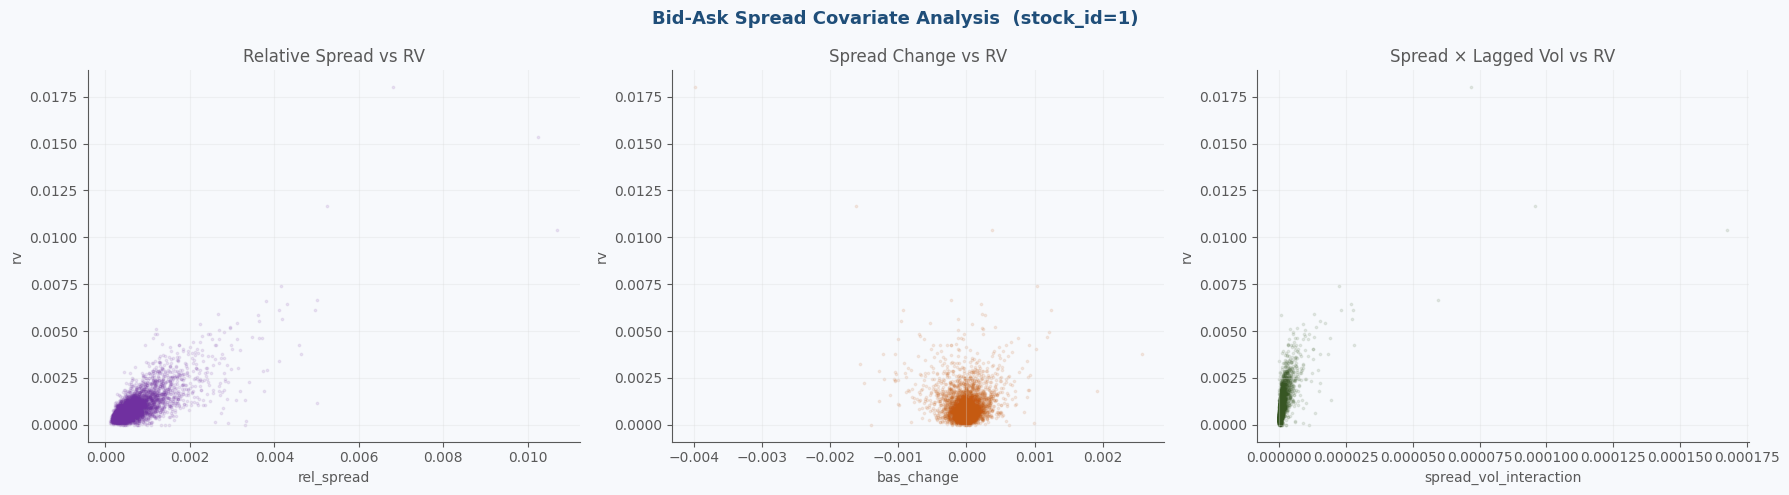

  Saved: spread_features_eda.png  ✓


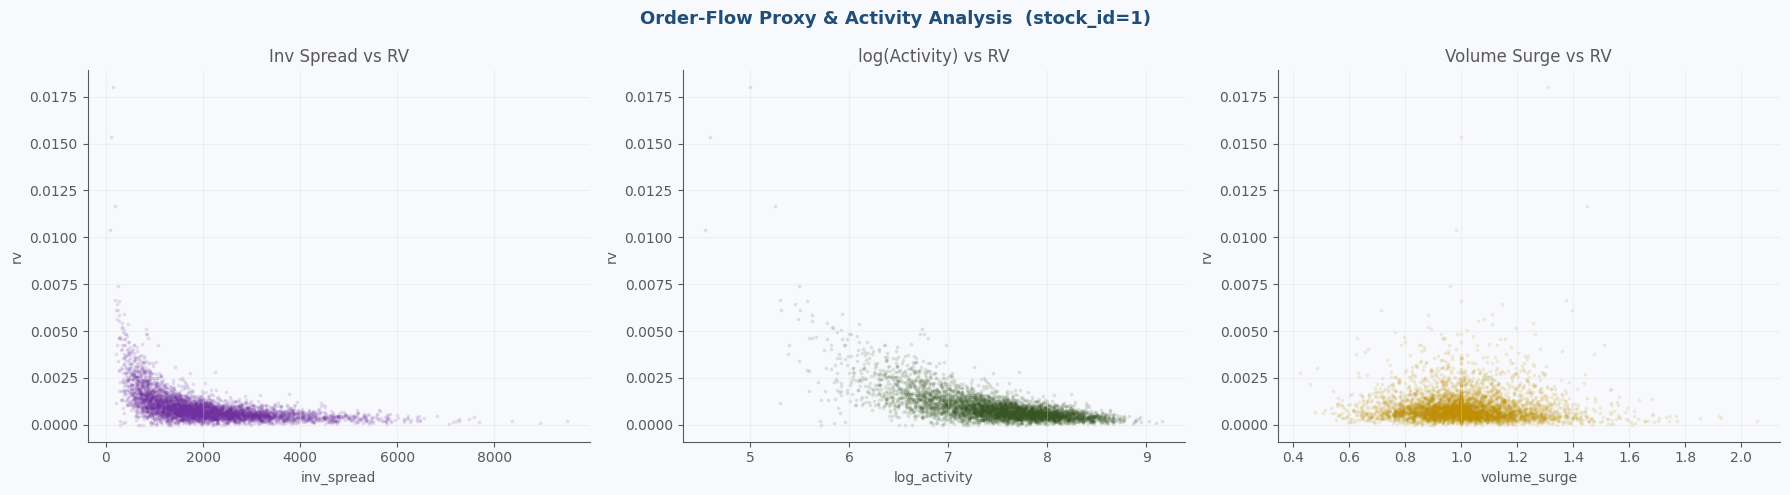

  Saved: order_flow_features_eda.png  ✓


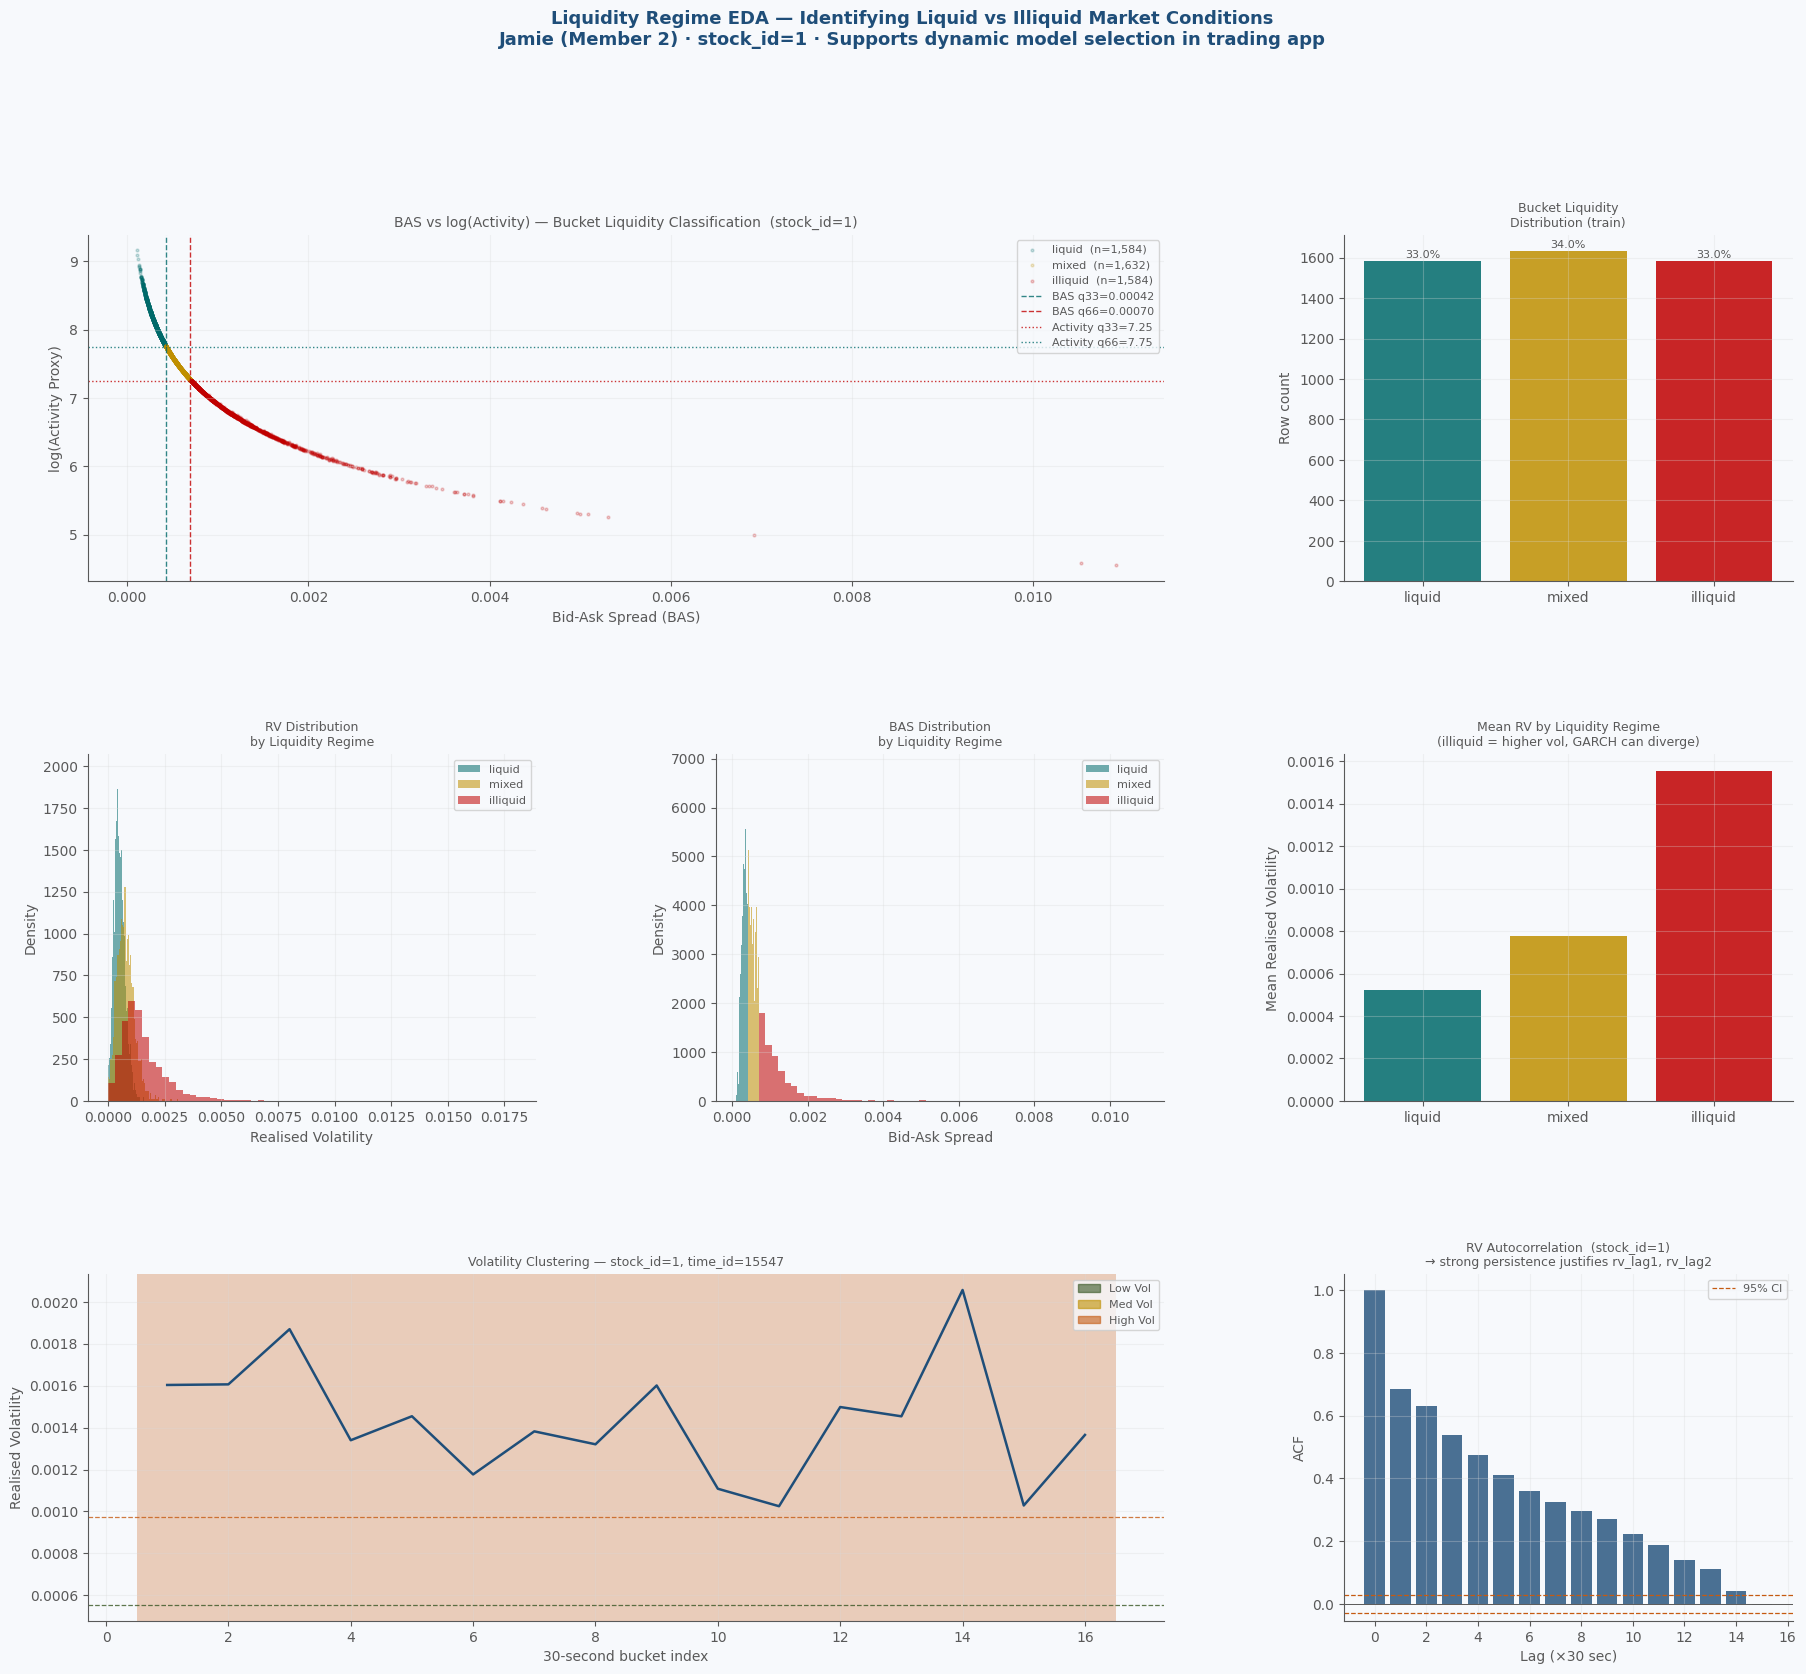

  Saved: liquidity_regime_eda.png  ✓


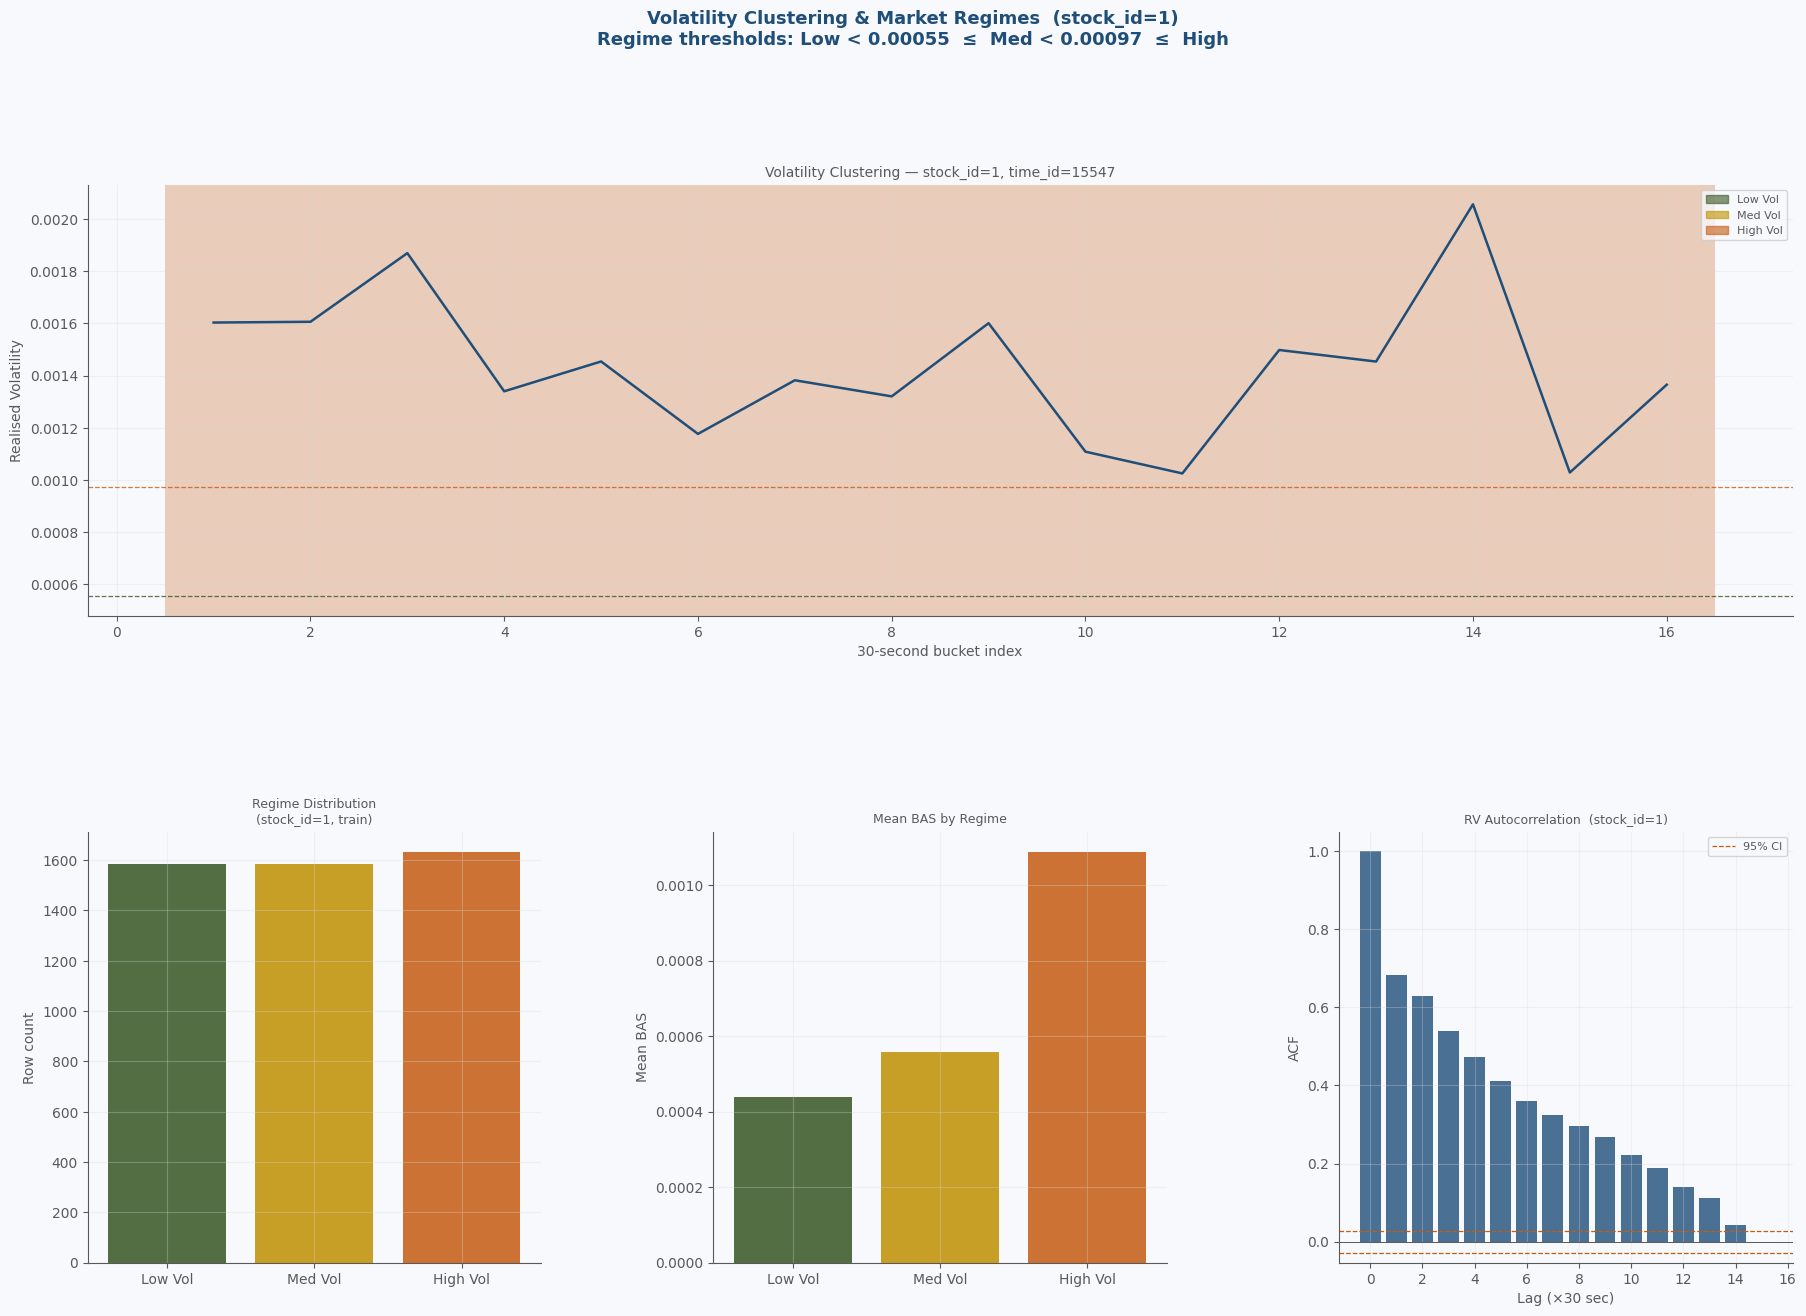

  Saved: cluster_plots.png  ✓

  Holdout OLS  MSE=0.00000005  QLIKE=-6.288976
  Tuning alpha on holdout split …
  Holdout best α = 0.61
  Holdout WLS  MSE=0.00000003  QLIKE=-6.290145

  Running 5-fold time-series CV on stock_id=1 …
  CV split strategy: TimeSeriesSplit(n_splits=5)
  Each fold trains on earlier time_buckets, validates on later ones.

    [CV] Fold 1:  tr_buckets=4–6  val_buckets=7–8  α=0.05  WLS_QLIKE=-6.188509  OLS_QLIKE=25.047265
    [CV] Fold 2:  tr_buckets=4–8  val_buckets=9–10  α=0.99  WLS_QLIKE=-6.181983  OLS_QLIKE=-6.181985
    [CV] Fold 3:  tr_buckets=4–10  val_buckets=11–12  α=0.64  WLS_QLIKE=15.579120  OLS_QLIKE=15.583792
    [CV] Fold 4:  tr_buckets=4–12  val_buckets=13–14  α=0.98  WLS_QLIKE=-6.192364  OLS_QLIKE=-6.192363
    [CV] Fold 5:  tr_buckets=4–14  val_buckets=15–16  α=0.99  WLS_QLIKE=-6.206075  OLS_QLIKE=-6.206120

  ── CV SUMMARY  Phase 1 — stock_id=1 ──
  Metric                     Mean         Std         Min         Max
  ─────────────────────────

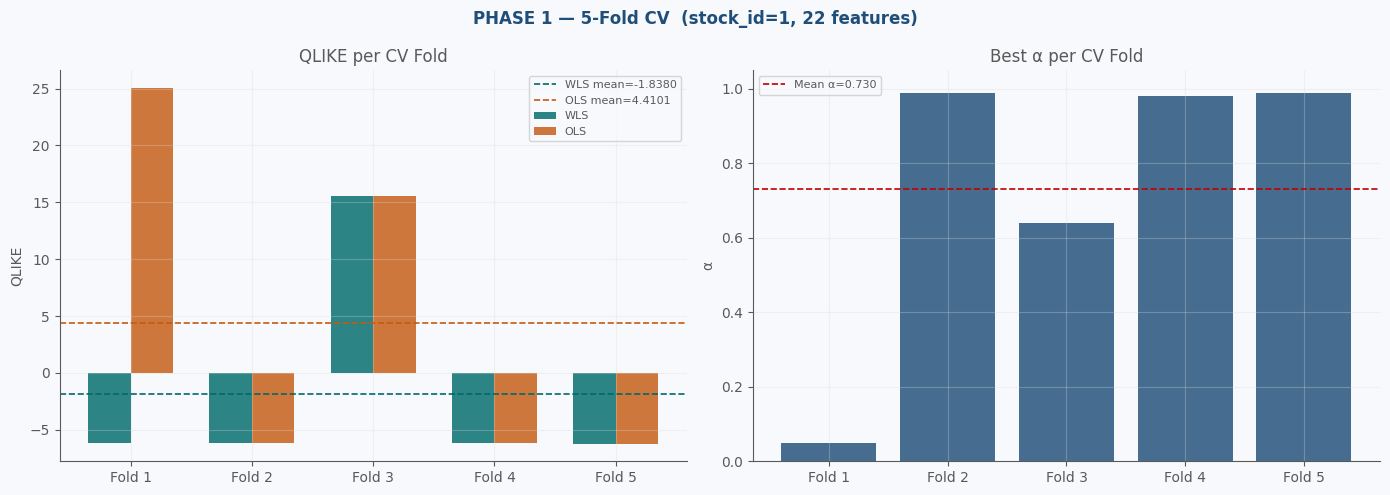

  Saved: /Users/jamiewood/Documents/DATA3888/DATA3888G08/phase1_cv_results.png  ✓


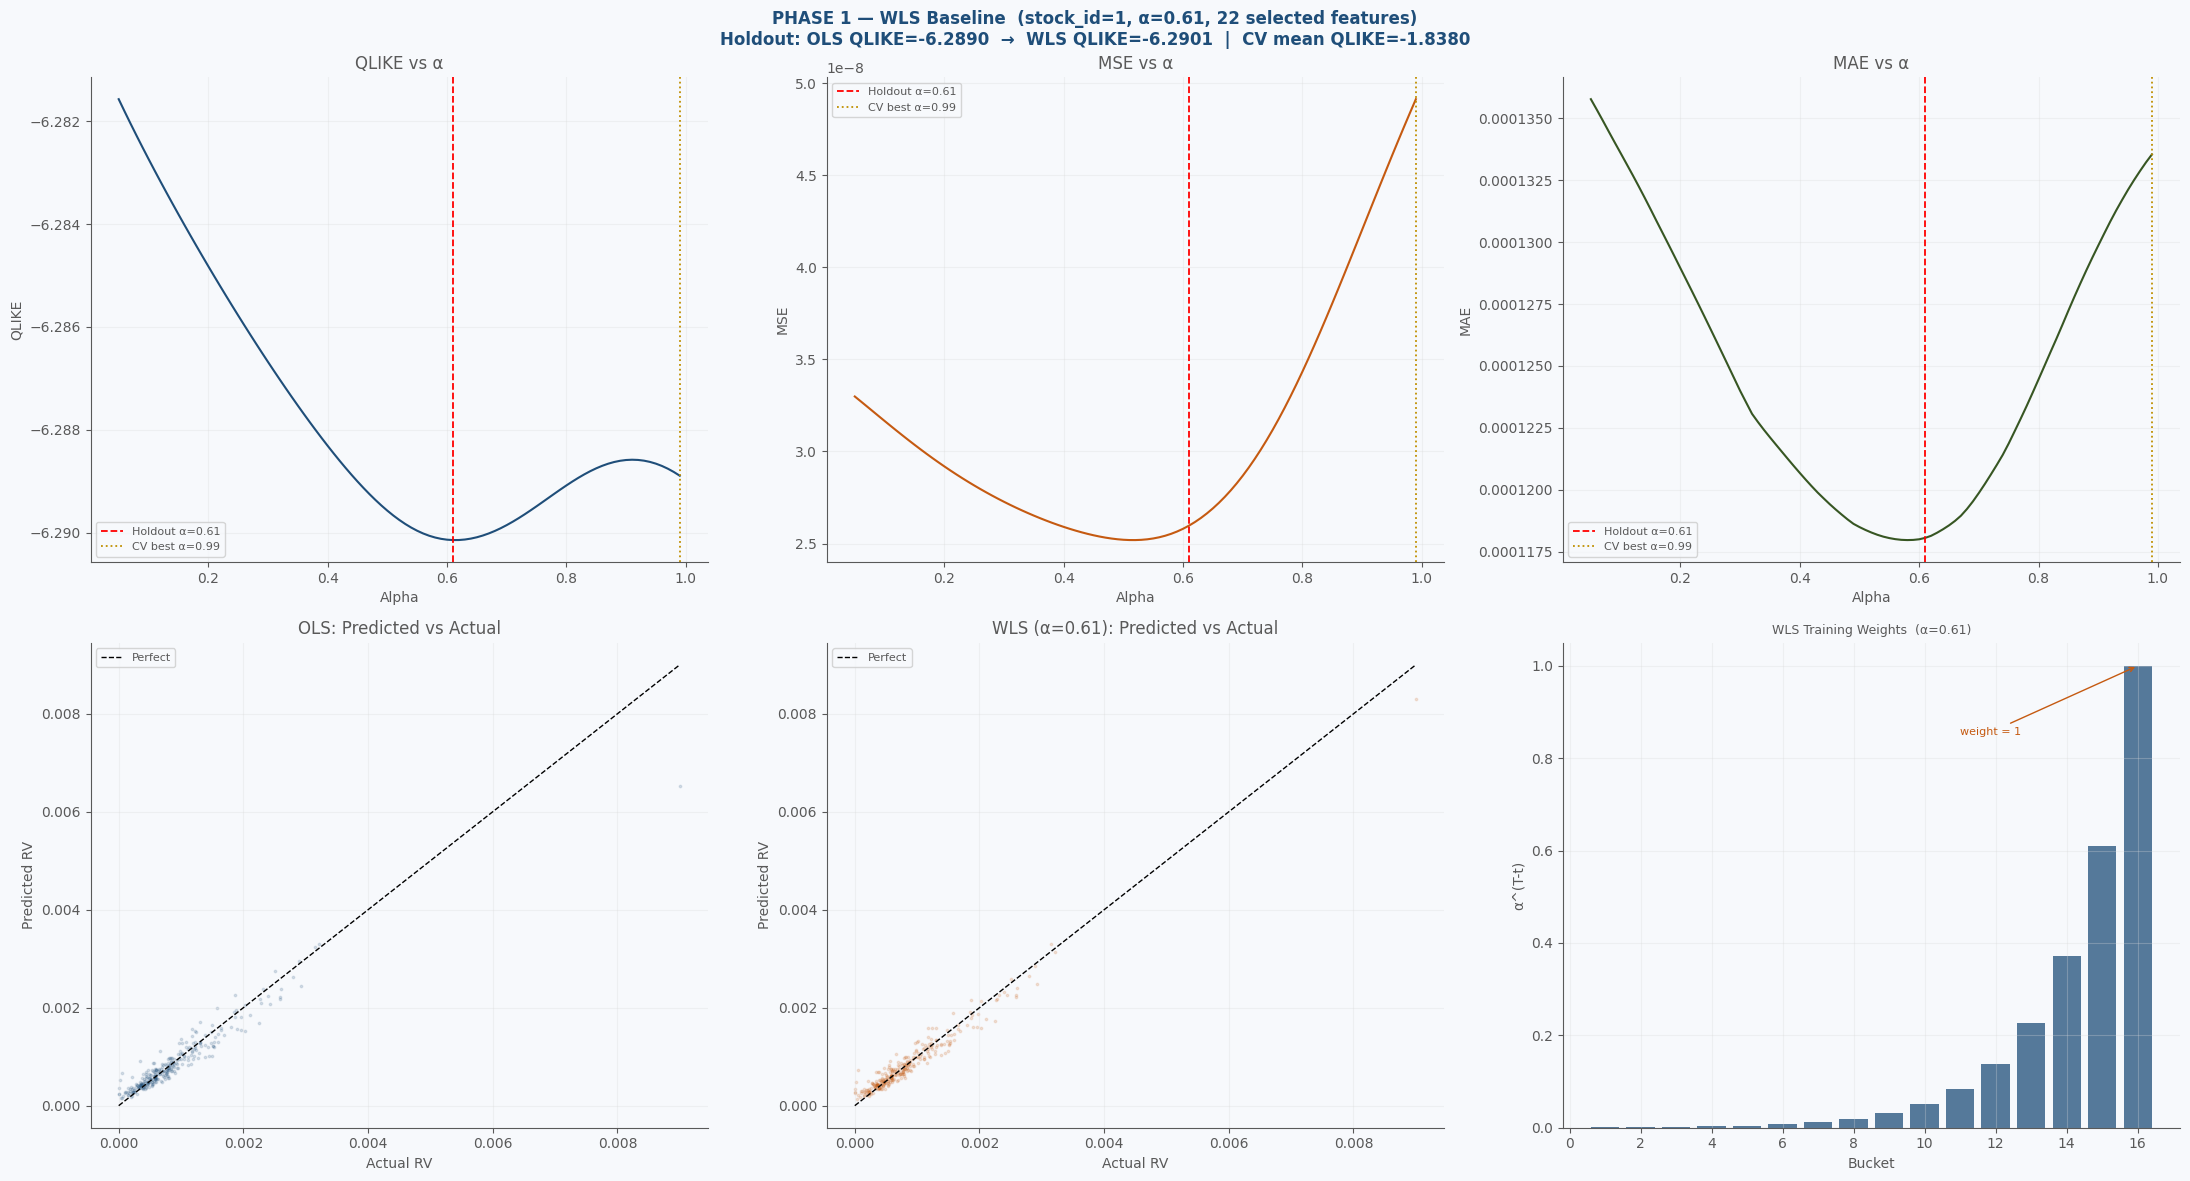

  Saved: phase1_wls_stock1.png  ✓

  ── PHASE 1 SUMMARY ──
  Holdout: OLS QLIKE=-6.288976  WLS QLIKE=-6.290145  α=0.61
  CV (5-fold): mean QLIKE=-1.837962  std=9.736449  best α=0.99

██████████████████████████████████████████████████████████████████████
PHASE 2 — LIQUIDITY CLASSIFICATION  (all stocks)
██████████████████████████████████████████████████████████████████████
  Engineering features on full train (537,059 rows) …
  Global BAS thresholds  : Low < 0.000297  ≤  Med < 0.000616  ≤  High
  Global Activity thresh : Low < 7.3658   ≤  Med < 8.0971   ≤  High

  Stock-level regime counts:
    illiquid  :   43 stocks (38.4%)
    liquid    :   39 stocks (34.8%)
    mixed     :   30 stocks (26.8%)

  ── DEMO STOCK SELECTION (random, seed=42) ──
  20 RANDOM LIQUID   stock_ids : [10, 13, 20, 28, 39, 46, 47, 50, 51, 52, 64, 68, 69, 77, 85, 86, 95, 99, 120, 124]
  20 RANDOM MIXED    stock_ids : [7, 19, 21, 26, 32, 42, 48, 59, 61, 70, 73, 76, 82, 89, 96, 101, 107, 113, 114, 115]
  20 RANDOM IL

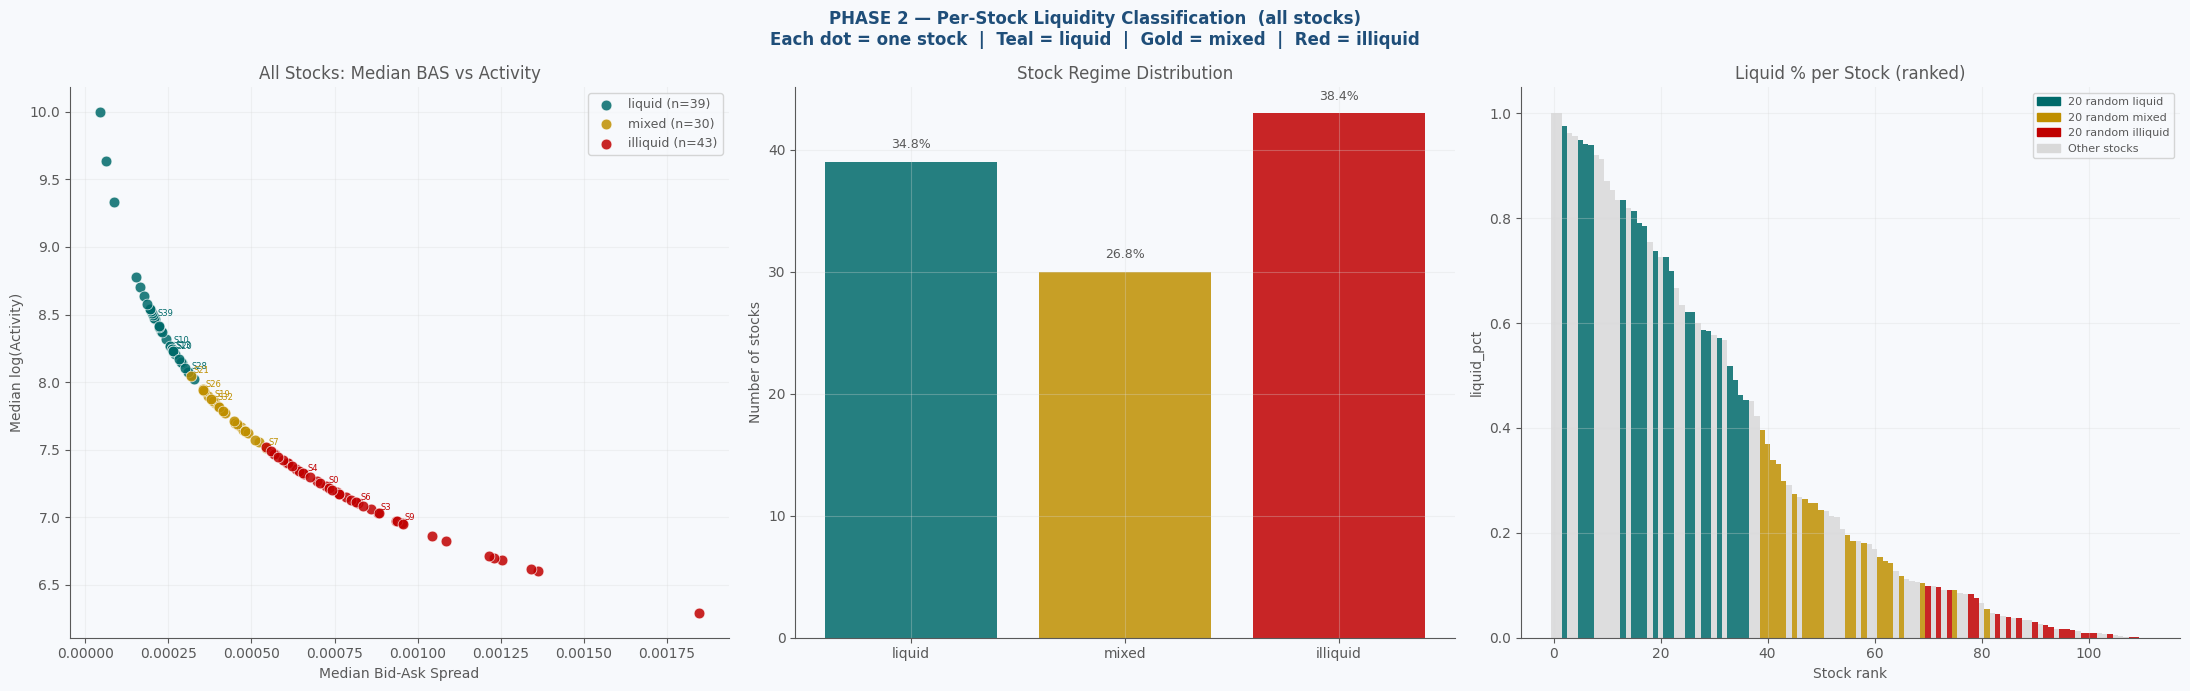

  Saved: phase2_all_stock_liquidity.png  ✓

██████████████████████████████████████████████████████████████████████
PHASE 3 — WLS + CV ON 60 DEMO STOCKS
  20 random liquid  +  20 random mixed  +  20 random illiquid
  Using 22 features selected in Phase 1
██████████████████████████████████████████████████████████████████████
  Engineering features …


In [ ]:
"""
Member 2 (Jamie): WLS Volatility Forecasting — Complete Three-Phase Pipeline
=============================================================================
  - Phase 3 uses 20 RANDOM liquid + 20 RANDOM mixed + 20 RANDOM illiquid stocks
  - A random subset of time_ids is sampled for speed + reproducibility
  - 5-fold time-series cross-validation (TimeSeriesSplit) is applied in ALL phases
  - All random seeds are fixed (RANDOM_SEED = 42) for reproducibility
  - Stock IDs and time IDs used are printed explicitly at runtime

FEATURE SELECTION is data-driven:
  1. Compute Pearson |r| with RV on stock_id=1 training data
  2. Drop features with |r| < MIN_CORR_THRESHOLD (default 0.05)
  3. Drop one of each highly collinear pair (|r_pair| > COLLINEARITY_THRESHOLD)
  4. FINAL_FEATURES is derived from the data, not hardcoded

PHASE 1 — WLS Baseline + CV on stock_id = 1
PHASE 2 — Liquidity Classification of ALL stocks
PHASE 3 — WLS + CV on 60 Demo Stocks (20 liquid + 20 mixed + 20 illiquid)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────
# PALETTE
# ─────────────────────────────────────────────────────────────────────
C_BLUE   = "#1F4E79"
C_ORANGE = "#C55A11"
C_GREEN  = "#375623"
C_PURPLE = "#7030A0"
C_GOLD   = "#BF8F00"
C_GREY   = "#595959"
C_LGREY  = "#D9D9D9"
C_BG     = "#F7F9FC"
C_RED    = "#C00000"
C_TEAL   = "#006A6A"
STOCK_COLORS = {"liquid": C_TEAL, "mixed": C_GOLD, "illiquid": C_RED}
LIQ_COLORS   = {"liquid": C_TEAL, "mixed": C_GOLD, "illiquid": C_RED}

plt.rcParams.update({
    "figure.facecolor":  C_BG,  "axes.facecolor":    C_BG,
    "axes.edgecolor":    C_GREY, "axes.labelcolor":   C_GREY,
    "xtick.color":       C_GREY, "ytick.color":       C_GREY,
    "text.color":        C_GREY, "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,  "axes.spines.right": False,
    "axes.grid":         True,   "grid.alpha":        0.3,
    "grid.color":        C_LGREY,
})

OUT = "/Users/jamiewood/Documents/DATA3888/DATA3888G08/"

# ─────────────────────────────────────────────────────────────────────
# KEY CONFIGURATION
# ─────────────────────────────────────────────────────────────────────
RANDOM_SEED        = 42          # fixed seed for full reproducibility
N_DEMO_PER_REGIME  = 20          # 20 random stocks per regime (liquid/mixed/illiquid)
N_TIME_IDS         = 300         # random subset of time_ids to keep (balances speed vs accuracy)
N_CV_FOLDS         = 5           # number of folds for TimeSeriesSplit cross-validation

# ─────────────────────────────────────────────────────────────────────
# FEATURE SELECTION THRESHOLDS
# ─────────────────────────────────────────────────────────────────────
MIN_CORR_THRESHOLD    = 0.05
COLLINEARITY_THRESHOLD = 0.95

BUCKET_SECONDS     = 30
WINDOW_SECONDS     = 600
N_EXPECTED_BUCKETS = WINDOW_SECONDS // BUCKET_SECONDS
TARGET = "rv"

# ─────────────────────────────────────────────────────────────────────
# CANDIDATE FEATURE POOL
# ─────────────────────────────────────────────────────────────────────
ALL_FEATURES = [
    "rv_lag1", "rv_lag2", "rv_lag3",
    "rv_roll_mean", "rv_roll_sd", "rv_roll_max", "rv_roll_cv",
    "bas", "bas_lag1", "rel_spread", "rel_spread_lag1",
    "bas_change", "bas_pct_change", "bas_roll_mean", "bas_roll_sd",
    "wap", "wap_return", "wap_return2", "wap_dev", "wap_accel",
    "inv_spread", "inv_spread_lag1", "log_activity", "log_activity_lag1",
    "spread_imbalance", "volume_surge",
    "spread_vol_interaction", "rel_spread_vol",
    "spread_change_vol", "activity_vol",
    "rv_lag1_sq", "bas_sq",
]

# ─────────────────────────────────────────────────────────────────────
# LOSS FUNCTIONS
# ─────────────────────────────────────────────────────────────────────
def qlike(y, yhat):
    yhat = np.maximum(yhat, 1e-8)
    return float(np.mean(np.log(yhat) + y / yhat))

def mse(y, yhat):  return float(np.mean((y - yhat) ** 2))
def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))

# ─────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df  = df.sort_values(["stock_id", "time_id", "time_bucket"]).copy()
    grp = df.groupby(["stock_id", "time_id"])
    df["rv_lag1"]      = grp["rv"].shift(1)
    df["rv_lag2"]      = grp["rv"].shift(2)
    df["rv_lag3"]      = grp["rv"].shift(3)
    df["rv_roll_mean"] = grp["rv"].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df["rv_roll_sd"]   = grp["rv"].transform(lambda x: x.rolling(5, min_periods=1).std())
    df["rv_roll_max"]  = grp["rv"].transform(lambda x: x.rolling(5, min_periods=1).max())
    df["rv_roll_cv"]   = df["rv_roll_sd"] / (df["rv_roll_mean"] + 1e-12)
    df["bas_lag1"]        = grp["bas"].shift(1)
    df["rel_spread"]      = df["bas"] / (df["wap"] + 1e-12)
    df["rel_spread_lag1"] = grp["rel_spread"].shift(1)
    df["bas_change"]      = df["bas"] - df["bas_lag1"]
    df["bas_pct_change"]  = df["bas_change"] / (df["bas_lag1"] + 1e-12)
    df["bas_roll_mean"]   = grp["bas"].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df["bas_roll_sd"]     = grp["bas"].transform(lambda x: x.rolling(5, min_periods=1).std())
    df["bas_sq"]          = df["bas"] ** 2
    df["wap_lag1"]      = grp["wap"].shift(1)
    df["wap_lag2"]      = grp["wap"].shift(2)
    df["wap_return"]    = np.log(df["wap"] / (df["wap_lag1"] + 1e-12))
    df["wap_return2"]   = np.log(df["wap"] / (df["wap_lag2"] + 1e-12))
    df["wap_roll_mean"] = grp["wap"].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df["wap_dev"]       = df["wap"] - df["wap_roll_mean"]
    df["wap_accel"]     = df["wap_return"] - grp["wap_return"].shift(1)
    df["inv_spread"]        = 1.0 / (df["bas"] + 1e-6)
    df["inv_spread_lag1"]   = grp["inv_spread"].shift(1)
    df["inv_spread_roll"]   = grp["inv_spread"].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df["activity_proxy"]    = df["wap"] * df["inv_spread"]
    df["log_activity"]      = np.log1p(df["activity_proxy"])
    df["log_activity_lag1"] = grp["log_activity"].shift(1)
    df["spread_imbalance"]  = df["bas_pct_change"]
    df["volume_surge"]      = df["inv_spread"] / (df["inv_spread_roll"] + 1e-12)
    df["spread_vol_interaction"] = df["bas"]          * df["rv_lag1"]
    df["rel_spread_vol"]         = df["rel_spread"]   * df["rv_lag1"]
    df["spread_change_vol"]      = df["bas_change"]   * df["rv_lag1"]
    df["activity_vol"]           = df["log_activity"] * df["rv_lag1"]
    df["wap_vol_interaction"]    = df["wap_return"]   * df["rv_lag1"]
    df["rv_lag1_sq"] = df["rv_lag1"] ** 2
    return df

# ─────────────────────────────────────────────────────────────────────
# DATA-DRIVEN FEATURE SELECTION
# ─────────────────────────────────────────────────────────────────────
def select_features(train_df, candidate_features, target,
                    min_corr=MIN_CORR_THRESHOLD,
                    collinearity_thresh=COLLINEARITY_THRESHOLD,
                    sample_n=50_000, random_state=RANDOM_SEED):
    sample = train_df[candidate_features + [target]].dropna()
    if len(sample) > sample_n:
        sample = sample.sample(sample_n, random_state=random_state)
    rv_corrs = (sample.corr()[target]
                .drop(target)
                .reindex(candidate_features)
                .dropna())
    print(f"\n  [FEATURE SELECTION] Candidate pool : {len(rv_corrs)} features")
    strong = rv_corrs[rv_corrs.abs() >= min_corr]
    dropped_weak = sorted(set(candidate_features) - set(strong.index) -
                          {f for f in candidate_features if f not in rv_corrs.index})
    print(f"  [FEATURE SELECTION] Dropped (|r| < {min_corr}): {dropped_weak}")
    feature_corr = sample[strong.index.tolist()].corr().abs()
    kept = list(strong.index)
    dropped_collinear = []
    for i in range(len(kept)):
        if kept[i] is None:
            continue
        for j in range(i + 1, len(kept)):
            if kept[j] is None:
                continue
            if feature_corr.loc[kept[i], kept[j]] > collinearity_thresh:
                ri = abs(rv_corrs[kept[i]])
                rj = abs(rv_corrs[kept[j]])
                drop = kept[j] if ri >= rj else kept[i]
                dropped_collinear.append(drop)
                if drop == kept[i]:
                    kept[i] = None
                    break
                else:
                    kept[j] = None
    kept = [f for f in kept if f is not None]
    print(f"  [FEATURE SELECTION] Dropped (collinear > {collinearity_thresh}): {sorted(dropped_collinear)}")
    final = sorted(kept, key=lambda f: abs(rv_corrs[f]), reverse=True)
    print(f"  [FEATURE SELECTION] Final features ({len(final)}): {final}")
    return final, rv_corrs

# ─────────────────────────────────────────────────────────────────────
# SHARED PIPELINE HELPERS
# ─────────────────────────────────────────────────────────────────────
def train_val_split(df):
    """80/20 holdout split on time_bucket order (used for final evaluation)."""
    sorted_b  = sorted(df["time_bucket"].unique())
    n_train   = int(len(sorted_b) * 0.8)
    train_max = sorted_b[n_train - 1]
    return (df[df["time_bucket"] <= train_max].copy(),
            df[df["time_bucket"] >  train_max].copy(),
            sorted_b, n_train, train_max)

def tune_alpha(X_tr, y_tr, X_te, y_te, train_max, bv):
    """Grid-search alpha on a single train/val split."""
    alpha_grid = np.round(np.arange(0.05, 1.00, 0.01), 3)
    def _fit(a):
        w    = a ** (train_max - bv)
        pred = np.maximum(LinearRegression().fit(X_tr, y_tr, sample_weight=w).predict(X_te), 1e-8)
        return {"alpha": a, "qlike": qlike(y_te, pred),
                "mse":   mse(y_te, pred), "mae": mae(y_te, pred)}
    results = Parallel(n_jobs=-1)([delayed(_fit)(a) for a in alpha_grid])
    tdf = pd.DataFrame(results)
    return float(tdf.loc[tdf["qlike"].idxmin(), "alpha"]), tdf

def label_bucket_liquidity(frame, bas_q33, bas_q66, act_q33, act_q66):
    def _label(r):
        if r["bas"] <= bas_q33 and r["log_activity"] >= act_q66: return "liquid"
        if r["bas"] >= bas_q66 and r["log_activity"] <= act_q33: return "illiquid"
        return "mixed"
    frame["bucket_liquidity"] = frame.apply(_label, axis=1)
    return frame

def feature_group_color(feat):
    if "rv" in feat and "spread" not in feat and "activity" not in feat: return C_BLUE
    if feat in ("bas","bas_lag1","rel_spread","rel_spread_lag1","bas_change",
                "bas_pct_change","bas_roll_mean","bas_roll_sd","bas_sq"):    return C_ORANGE
    if "activity" in feat or "inv_spread" in feat or "imbalance" in feat \
            or "volume_surge" in feat:                                        return C_GREEN
    if "wap" in feat:                                                         return C_GOLD
    return C_GREY

# ─────────────────────────────────────────────────────────────────────
# CROSS-VALIDATION HELPERS
# ─────────────────────────────────────────────────────────────────────
def wls_cv_on_df(df_feat, features, target, n_splits=N_CV_FOLDS):
    """
    Time-series k-fold CV for WLS on a pre-featured DataFrame.

    Strategy
    --------
    We split on *sorted time_bucket* values so that each fold always
    trains on earlier buckets and validates on later ones — preserving
    temporal order and preventing look-ahead leakage.

    For each fold:
      1. Find the best alpha via grid-search on that fold's train/val split.
      2. Fit WLS with that alpha.
      3. Record QLIKE, MSE, MAE on the fold's validation set.

    Returns
    -------
    cv_results : list of dicts  (one per fold)
    best_alpha : float           (alpha from the fold with best QLIKE)
    """
    df_clean  = df_feat.dropna(subset=features + [target]).copy()
    sorted_b  = np.array(sorted(df_clean["time_bucket"].unique()))
    n_buckets = len(sorted_b)

    # TimeSeriesSplit works on bucket indices, not row indices
    tss = TimeSeriesSplit(n_splits=n_splits)
    cv_results = []

    for fold_idx, (tr_idx, te_idx) in enumerate(tss.split(sorted_b)):
        tr_buckets = sorted_b[tr_idx]
        te_buckets = sorted_b[te_idx]
        tr_max     = tr_buckets[-1]

        tr = df_clean[df_clean["time_bucket"].isin(tr_buckets)]
        te = df_clean[df_clean["time_bucket"].isin(te_buckets)]

        if len(tr) < 50 or len(te) < 10:
            print(f"    [CV] Fold {fold_idx+1}: skipped (too few rows — tr={len(tr)}, te={len(te)})")
            continue

        X_tr = tr[features].values;  y_tr = tr[target].values
        X_te = te[features].values;  y_te = te[target].values
        bv   = tr["time_bucket"].values

        # tune alpha on this fold
        best_a, _ = tune_alpha(X_tr, y_tr, X_te, y_te, tr_max, bv)
        w         = best_a ** (tr_max - bv)
        wls       = LinearRegression().fit(X_tr, y_tr, sample_weight=w)
        pred      = np.maximum(wls.predict(X_te), 1e-8)

        # OLS baseline for comparison
        ols  = LinearRegression().fit(X_tr, y_tr)
        pred_ols = np.maximum(ols.predict(X_te), 1e-8)

        fold_res = {
            "fold":       fold_idx + 1,
            "n_train":    len(tr),
            "n_val":      len(te),
            "tr_buckets": f"{tr_buckets[0]}–{tr_buckets[-1]}",
            "val_buckets":f"{te_buckets[0]}–{te_buckets[-1]}",
            "best_alpha": best_a,
            "wls_qlike":  qlike(y_te, pred),
            "wls_mse":    mse(y_te, pred),
            "wls_mae":    mae(y_te, pred),
            "ols_qlike":  qlike(y_te, pred_ols),
        }
        cv_results.append(fold_res)
        print(f"    [CV] Fold {fold_idx+1}:  "
              f"tr_buckets={fold_res['tr_buckets']}  val_buckets={fold_res['val_buckets']}  "
              f"α={best_a:.2f}  WLS_QLIKE={fold_res['wls_qlike']:.6f}  "
              f"OLS_QLIKE={fold_res['ols_qlike']:.6f}")

    cv_df = pd.DataFrame(cv_results)
    best_alpha_cv = (cv_df.loc[cv_df["wls_qlike"].idxmin(), "best_alpha"]
                     if len(cv_df) > 0 else 0.99)
    return cv_results, float(best_alpha_cv)


def print_cv_summary(cv_results, label=""):
    """Pretty-print mean ± std of CV metrics."""
    if not cv_results:
        print("  [CV] No results to summarise.")
        return
    cv_df = pd.DataFrame(cv_results)
    print(f"\n  ── CV SUMMARY  {label} ──")
    print(f"  {'Metric':<20} {'Mean':>10}  {'Std':>10}  {'Min':>10}  {'Max':>10}")
    print("  " + "─" * 60)
    for col in ["wls_qlike", "wls_mse", "wls_mae", "ols_qlike", "best_alpha"]:
        print(f"  {col:<20} {cv_df[col].mean():>10.6f}  "
              f"{cv_df[col].std():>10.6f}  "
              f"{cv_df[col].min():>10.6f}  "
              f"{cv_df[col].max():>10.6f}")
    print(f"\n  Fold details:")
    for _, r in cv_df.iterrows():
        print(f"    Fold {int(r['fold'])}: "
              f"train_buckets={r['tr_buckets']}  val_buckets={r['val_buckets']}  "
              f"n_train={int(r['n_train'])}  n_val={int(r['n_val'])}  "
              f"α={r['best_alpha']:.2f}  QLIKE={r['wls_qlike']:.6f}")


def plot_cv_results(cv_results, title, save_path):
    """Bar chart of per-fold WLS vs OLS QLIKE."""
    if not cv_results:
        return
    cv_df = pd.DataFrame(cv_results)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(C_BG)
    fig.suptitle(title, fontsize=12, fontweight="bold", color=C_BLUE)

    x = np.arange(len(cv_df))
    w = 0.35
    axes[0].bar(x - w/2, cv_df["wls_qlike"], w, color=C_TEAL, alpha=0.82, label="WLS")
    axes[0].bar(x + w/2, cv_df["ols_qlike"], w, color=C_ORANGE, alpha=0.82, label="OLS")
    axes[0].axhline(cv_df["wls_qlike"].mean(), color=C_TEAL,   linestyle="--", lw=1.2,
                    label=f"WLS mean={cv_df['wls_qlike'].mean():.4f}")
    axes[0].axhline(cv_df["ols_qlike"].mean(), color=C_ORANGE, linestyle="--", lw=1.2,
                    label=f"OLS mean={cv_df['ols_qlike'].mean():.4f}")
    axes[0].set_xticks(x); axes[0].set_xticklabels([f"Fold {i+1}" for i in x])
    axes[0].set_title("QLIKE per CV Fold"); axes[0].set_ylabel("QLIKE")
    axes[0].legend(fontsize=8); axes[0].set_facecolor(C_BG)

    axes[1].bar(x, cv_df["best_alpha"], color=C_BLUE, alpha=0.82, edgecolor="none")
    axes[1].axhline(cv_df["best_alpha"].mean(), color=C_RED, linestyle="--", lw=1.2,
                    label=f"Mean α={cv_df['best_alpha'].mean():.3f}")
    axes[1].set_xticks(x); axes[1].set_xticklabels([f"Fold {i+1}" for i in x])
    axes[1].set_title("Best α per CV Fold"); axes[1].set_ylabel("α")
    axes[1].legend(fontsize=8); axes[1].set_facecolor(C_BG)
    axes[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved: {save_path}  ✓")


# ═════════════════════════════════════════════════════════════════════
# LOAD FULL DATASET
# ═════════════════════════════════════════════════════════════════════
print("=" * 70)
print("LOADING FULL DATASET")
print("=" * 70)
df_full = pd.read_csv(OUT + "optiver_aggregated.csv")
df_full = df_full[df_full["time_bucket"] > 0].copy()
df_full = df_full.rename(columns={
    "WAP_mean": "wap", "BidAskSpread_mean": "bas", "volatility": "rv"})
df_full = df_full.sort_values(["stock_id","time_id","time_bucket"]).reset_index(drop=True)
print(f"  Full dataset (bucket-0 dropped): {df_full.shape}")
print(f"  Unique stocks  : {df_full['stock_id'].nunique()}")
print(f"  Unique time_ids: {df_full['time_id'].nunique()}")

# ─────────────────────────────────────────────────────────────────────
# RANDOM time_id SUBSAMPLE
# Rationale: 300 time_ids gives ~300 × 20 buckets = 6,000 rows per stock,
# which is large enough for stable CV estimates while keeping runtime
# to a few minutes on a laptop. Seed is fixed so results are reproducible.
# ─────────────────────────────────────────────────────────────────────
all_time_ids = sorted(df_full["time_id"].unique())
rng = np.random.default_rng(RANDOM_SEED)

if len(all_time_ids) > N_TIME_IDS:
    sampled_time_ids = sorted(rng.choice(all_time_ids, size=N_TIME_IDS, replace=False).tolist())
    df_full = df_full[df_full["time_id"].isin(sampled_time_ids)].copy()
    print(f"\n  ── TIME_ID SUBSAMPLE ──")
    print(f"  Sampled {N_TIME_IDS} of {len(all_time_ids)} time_ids  (seed={RANDOM_SEED})")
    print(f"  Sampled time_ids: {sampled_time_ids}")
else:
    sampled_time_ids = all_time_ids
    print(f"  Using all {len(all_time_ids)} time_ids (fewer than requested {N_TIME_IDS})")

print(f"  Dataset after time_id filter: {df_full.shape}")


# ═══════════════════════════════════════════════════════════════════════
# ██  PHASE 1 — WLS BASELINE + CV  (stock_id = 1 only)  ██████████████
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "█" * 70)
print("PHASE 1 — WLS BASELINE + CROSS-VALIDATION  (stock_id = 1)")
print("█" * 70)

df1 = df_full[df_full["stock_id"] == 1].copy()
print(f"  stock_id=1 rows: {len(df1):,}")

train1, test1, sorted_b1, n_train1, train_max1 = train_val_split(df1)
print(f"  Holdout split — Train buckets: 1–{train_max1}  |  Test buckets: {train_max1+1}–{sorted_b1[-1]}")
print(f"  Train rows: {len(train1):,}   Test rows: {len(test1):,}")

print("  Engineering features …")
train1 = add_features(train1);  test1 = add_features(test1)

bas_q33_1 = train1["bas"].quantile(0.33); bas_q66_1 = train1["bas"].quantile(0.66)
act_q33_1 = train1["log_activity"].quantile(0.33); act_q66_1 = train1["log_activity"].quantile(0.66)
train1 = label_bucket_liquidity(train1, bas_q33_1, bas_q66_1, act_q33_1, act_q66_1)
test1  = label_bucket_liquidity(test1,  bas_q33_1, bas_q66_1, act_q33_1, act_q66_1)

# ── DATA-DRIVEN FEATURE SELECTION ─────────────────────────────────────
print("\n  Running data-driven feature selection on stock_id=1 training data …")
FINAL_FEATURES, rv_corrs = select_features(
    train1, ALL_FEATURES, TARGET,
    min_corr=MIN_CORR_THRESHOLD,
    collinearity_thresh=COLLINEARITY_THRESHOLD,
)

print(f"\n  ── SELECTED FEATURES ({len(FINAL_FEATURES)}) ──")
print(f"  {'Feature':<30} {'|r with RV|':>12}  {'r':>8}  Group")
print("  " + "─" * 65)
for f in FINAL_FEATURES:
    r = rv_corrs.get(f, np.nan)
    grp = feature_group_color(f)
    grp_name = ("RV lags/rolling" if grp == C_BLUE else
                 "Bid-Ask Spread"  if grp == C_ORANGE else
                 "Order-flow"      if grp == C_GREEN else
                 "Price (WAP)"     if grp == C_GOLD else "Interaction/nonlinear")
    print(f"  {f:<30} {abs(r):>12.4f}  {r:>+8.4f}  {grp_name}")

# ── EDA sample ────────────────────────────────────────────────────────
eda1 = train1.sample(min(50_000, len(train1)), random_state=RANDOM_SEED)
rv_corrs_full = (eda1[ALL_FEATURES + [TARGET]].dropna().corr()[TARGET]
                 .drop(TARGET).sort_values(key=abs, ascending=False))

# ─────────────────────────────────────────────────────────────────────
# EDA PLOTS (unchanged from original)
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.patch.set_facecolor(C_BG)
fig.suptitle("EDA — Covariate Distributions  (stock_id=1, 30-second buckets)",
             fontsize=14, fontweight="bold", color=C_BLUE, y=1.01)
axes[0,0].hist(train1["rv"].dropna(), bins=100, color=C_BLUE, edgecolor="none", alpha=0.85)
axes[0,0].set_title("Realised Volatility  [TARGET]"); axes[0,0].set_xlabel("rv"); axes[0,0].set_ylabel("Count")
axes[0,1].hist(train1["bas"].dropna(), bins=100, color=C_ORANGE, edgecolor="none", alpha=0.85)
axes[0,1].set_title("Bid-Ask Spread  [SPREAD COVARIATE]"); axes[0,1].set_xlabel("bas")
axes[0,2].hist(eda1["rel_spread"].dropna(), bins=80, color=C_PURPLE, edgecolor="none", alpha=0.85)
axes[0,2].set_title("Relative Spread = BAS / WAP  [NORMALISED SPREAD]"); axes[0,2].set_xlabel("rel_spread")
axes[1,0].hist(eda1["log_activity"].dropna(), bins=100, color=C_GREEN, edgecolor="none", alpha=0.85)
axes[1,0].set_title("log(Activity Proxy)  [ORDER-FLOW COVARIATE]"); axes[1,0].set_xlabel("log_activity")
axes[1,1].hist(eda1["inv_spread"].dropna(), bins=80, color=C_GOLD, edgecolor="none", alpha=0.85)
axes[1,1].set_title("Inverse Spread  [NUM-ORDERS PROXY]"); axes[1,1].set_xlabel("inv_spread")
axes[1,2].scatter(eda1["rv_lag1"], eda1["rv"], alpha=0.1, s=3, color=C_BLUE)
axes[1,2].set_title("RV Lag-1 vs RV  (persistence)"); axes[1,2].set_xlabel("rv_lag1"); axes[1,2].set_ylabel("rv")
plt.tight_layout()
plt.savefig(OUT + "eda_distributions.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: eda_distributions.png  ✓")

top_n        = min(len(rv_corrs_full), 28)
rv_corrs_top = rv_corrs_full.head(top_n)
bar_colors   = [feature_group_color(f) if f in FINAL_FEATURES else C_LGREY for f in rv_corrs_top.index]
fig, ax = plt.subplots(figsize=(15, 9)); fig.patch.set_facecolor(C_BG); ax.set_facecolor(C_BG)
ax.barh(range(top_n), rv_corrs_top.values.astype(float), color=bar_colors, alpha=0.88, edgecolor="none")
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"★ {f}" if f in FINAL_FEATURES else f"  {f}" for f in rv_corrs_top.index], fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color=C_GREY, linewidth=0.8)
ax.axvline( MIN_CORR_THRESHOLD, color=C_RED, linestyle=":", lw=1.2)
ax.axvline(-MIN_CORR_THRESHOLD, color=C_RED, linestyle=":", lw=1.2)
ax.set_xlabel("Pearson r with Realised Volatility", fontsize=10)
ax.set_title(f"Feature Selection — Correlation with RV  (stock_id=1, DATA-DRIVEN)\n"
             f"★ = selected ({len(FINAL_FEATURES)} features)  |  Grey = dropped  |  "
             f"Threshold: |r| ≥ {MIN_CORR_THRESHOLD}, collinearity < {COLLINEARITY_THRESHOLD}",
             fontsize=11, fontweight="bold", color=C_BLUE)
legend_items = [
    mpatches.Patch(color=C_BLUE,   label="RV lags / rolling  ★ selected"),
    mpatches.Patch(color=C_ORANGE, label="Bid-Ask Spread      ★ selected"),
    mpatches.Patch(color=C_GREEN,  label="Order-flow proxies  ★ selected"),
    mpatches.Patch(color=C_GOLD,   label="Price (WAP)         ★ selected"),
    mpatches.Patch(color=C_GREY,   label="Interaction/nonlinear ★ selected"),
    mpatches.Patch(color=C_LGREY,  label="Dropped (weak or collinear)"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(OUT + "feature_selection_correlation.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: feature_selection_correlation.png  ✓")

heatmap_cols = [TARGET] + FINAL_FEATURES[:12]
corr_matrix  = eda1[heatmap_cols].dropna().corr()
plt.figure(figsize=(14, 12)); plt.gca().set_facecolor(C_BG)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, mask=mask, linewidths=0.4, annot_kws={"size": 8})
plt.title(f"Correlation Matrix — Selected Covariates  (stock_id=1, top {len(heatmap_cols)-1} features)\n"
          "(Price  ·  Bid-Ask Spread  ·  Order-Flow  ·  RV Lags)",
          fontsize=12, fontweight="bold", color=C_BLUE)
plt.tight_layout()
plt.savefig(OUT + "correlation_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: correlation_heatmap.png  ✓")

# Spread & order-flow EDA plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5)); fig.patch.set_facecolor(C_BG)
fig.suptitle("Bid-Ask Spread Covariate Analysis  (stock_id=1)", fontsize=13, fontweight="bold", color=C_BLUE)
axes[0].scatter(eda1["rel_spread"], eda1["rv"], alpha=0.1, s=3, color=C_PURPLE)
axes[0].set_title("Relative Spread vs RV"); axes[0].set_xlabel("rel_spread"); axes[0].set_ylabel("rv")
axes[1].scatter(eda1["bas_change"], eda1["rv"], alpha=0.1, s=3, color=C_ORANGE)
axes[1].set_title("Spread Change vs RV"); axes[1].set_xlabel("bas_change"); axes[1].set_ylabel("rv")
axes[2].scatter(eda1["spread_vol_interaction"], eda1["rv"], alpha=0.1, s=3, color=C_GREEN)
axes[2].set_title("Spread × Lagged Vol vs RV"); axes[2].set_xlabel("spread_vol_interaction"); axes[2].set_ylabel("rv")
plt.tight_layout()
plt.savefig(OUT + "spread_features_eda.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: spread_features_eda.png  ✓")

fig, axes = plt.subplots(1, 3, figsize=(18, 5)); fig.patch.set_facecolor(C_BG)
fig.suptitle("Order-Flow Proxy & Activity Analysis  (stock_id=1)", fontsize=13, fontweight="bold", color=C_BLUE)
axes[0].scatter(eda1["inv_spread"], eda1["rv"], alpha=0.1, s=3, color=C_PURPLE)
axes[0].set_title("Inv Spread vs RV"); axes[0].set_xlabel("inv_spread"); axes[0].set_ylabel("rv")
axes[1].scatter(eda1["log_activity"], eda1["rv"], alpha=0.1, s=3, color=C_GREEN)
axes[1].set_title("log(Activity) vs RV"); axes[1].set_xlabel("log_activity"); axes[1].set_ylabel("rv")
axes[2].scatter(eda1["volume_surge"], eda1["rv"], alpha=0.1, s=3, color=C_GOLD)
axes[2].set_title("Volume Surge vs RV"); axes[2].set_xlabel("volume_surge"); axes[2].set_ylabel("rv")
plt.tight_layout()
plt.savefig(OUT + "order_flow_features_eda.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: order_flow_features_eda.png  ✓")

# Liquidity regime EDA plot
q33 = train1["rv"].quantile(0.33); q66 = train1["rv"].quantile(0.66)
def classify_regime(v):
    if v <= q33: return 0
    if v <= q66: return 1
    return 2
train1["regime"] = train1["rv"].apply(classify_regime)
test1["regime"]  = test1["rv"].apply(classify_regime)
REG_COLORS = {0: C_GREEN, 1: C_GOLD, 2: C_ORANGE}
REG_LABELS = {0: "Low Vol", 1: "Med Vol", 2: "High Vol"}
bc1 = train1["bucket_liquidity"].value_counts()
liq_labels = ["liquid", "mixed", "illiquid"]
sample_tids = train1["time_id"].unique()
sample_tid  = sample_tids[len(sample_tids) // 2]
sample_ts   = train1[train1["time_id"] == sample_tid].sort_values("time_bucket")
MAX_LAG  = 15
rv_series = train1.sort_values(["time_id","time_bucket"])["rv"].dropna().values
acf_vals  = np.array([np.corrcoef(rv_series[:-lag], rv_series[lag:])[0,1]
                      if lag > 0 else 1.0 for lag in range(MAX_LAG+1)])
ci = 1.96 / np.sqrt(len(rv_series))

fig = plt.figure(figsize=(22, 18)); fig.patch.set_facecolor(C_BG)
fig.suptitle("Liquidity Regime EDA — Identifying Liquid vs Illiquid Market Conditions\n"
             "Jamie (Member 2) · stock_id=1 · Supports dynamic model selection in trading app",
             fontsize=13, fontweight="bold", color=C_BLUE, y=1.005)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.40)
ax_sc = fig.add_subplot(gs[0, :2])
for regime, color in LIQ_COLORS.items():
    sub = eda1[eda1["bucket_liquidity"] == regime]
    ax_sc.scatter(sub["bas"], sub["log_activity"], alpha=0.20, s=4, color=color,
                  label=f"{regime}  (n={len(sub):,})")
ax_sc.axvline(bas_q33_1, color=C_TEAL, linestyle="--", lw=1.0, alpha=0.8, label=f"BAS q33={bas_q33_1:.5f}")
ax_sc.axvline(bas_q66_1, color=C_RED,  linestyle="--", lw=1.0, alpha=0.8, label=f"BAS q66={bas_q66_1:.5f}")
ax_sc.axhline(act_q33_1, color=C_RED,  linestyle=":",  lw=1.0, alpha=0.8, label=f"Activity q33={act_q33_1:.2f}")
ax_sc.axhline(act_q66_1, color=C_TEAL, linestyle=":",  lw=1.0, alpha=0.8, label=f"Activity q66={act_q66_1:.2f}")
ax_sc.set_title("BAS vs log(Activity) — Bucket Liquidity Classification  (stock_id=1)", fontsize=10)
ax_sc.set_xlabel("Bid-Ask Spread (BAS)"); ax_sc.set_ylabel("log(Activity Proxy)")
ax_sc.legend(fontsize=8, loc="upper right")
ax_reg = fig.add_subplot(gs[0, 2])
liq_cnts = [bc1.get(l, 0) for l in liq_labels]
ax_reg.bar(liq_labels, liq_cnts, color=[LIQ_COLORS[l] for l in liq_labels], alpha=0.85, edgecolor="none")
ax_reg.set_title("Bucket Liquidity\nDistribution (train)", fontsize=9)
ax_reg.set_ylabel("Row count")
for i, (lbl, cnt) in enumerate(zip(liq_labels, liq_cnts)):
    ax_reg.text(i, cnt + max(liq_cnts)*0.01, f"{100*cnt/sum(liq_cnts):.1f}%", ha="center", fontsize=8)
ax_rv = fig.add_subplot(gs[1, 0])
for regime, color in LIQ_COLORS.items():
    vals = eda1.loc[eda1["bucket_liquidity"] == regime, "rv"].dropna()
    ax_rv.hist(vals, bins=60, color=color, alpha=0.55, edgecolor="none", label=regime, density=True)
ax_rv.set_title("RV Distribution\nby Liquidity Regime", fontsize=9)
ax_rv.set_xlabel("Realised Volatility"); ax_rv.set_ylabel("Density"); ax_rv.legend(fontsize=8)
ax_bas = fig.add_subplot(gs[1, 1])
for regime, color in LIQ_COLORS.items():
    vals = eda1.loc[eda1["bucket_liquidity"] == regime, "bas"].dropna()
    ax_bas.hist(vals, bins=60, color=color, alpha=0.55, edgecolor="none", label=regime, density=True)
ax_bas.set_title("BAS Distribution\nby Liquidity Regime", fontsize=9)
ax_bas.set_xlabel("Bid-Ask Spread"); ax_bas.set_ylabel("Density"); ax_bas.legend(fontsize=8)
ax_mrv = fig.add_subplot(gs[1, 2])
mean_rv_by_regime = eda1.groupby("bucket_liquidity")["rv"].mean()
ax_mrv.bar([l for l in liq_labels if l in mean_rv_by_regime.index],
           [mean_rv_by_regime.get(l, 0) for l in liq_labels if l in mean_rv_by_regime.index],
           color=[LIQ_COLORS[l] for l in liq_labels if l in mean_rv_by_regime.index], alpha=0.85, edgecolor="none")
ax_mrv.set_title("Mean RV by Liquidity Regime\n(illiquid = higher vol, GARCH can diverge)", fontsize=9)
ax_mrv.set_ylabel("Mean Realised Volatility")
ax_ts = fig.add_subplot(gs[2, :2])
for _, row in sample_ts.iterrows():
    ax_ts.axvspan(row["time_bucket"]-0.5, row["time_bucket"]+0.5,
                  color=REG_COLORS[row["regime"]], alpha=0.28, linewidth=0)
ax_ts.plot(sample_ts["time_bucket"], sample_ts["rv"], color=C_BLUE, lw=1.8, zorder=3)
ax_ts.axhline(q33, color=C_GREEN,  linestyle="--", lw=0.9, alpha=0.8, label=f"q33={q33:.5f}")
ax_ts.axhline(q66, color=C_ORANGE, linestyle="--", lw=0.9, alpha=0.8, label=f"q66={q66:.5f}")
ax_ts.set_title(f"Volatility Clustering — stock_id=1, time_id={sample_tid}", fontsize=9)
ax_ts.set_xlabel("30-second bucket index"); ax_ts.set_ylabel("Realised Volatility")
regime_patches = [mpatches.Patch(color=REG_COLORS[r], alpha=0.6, label=REG_LABELS[r]) for r in [0,1,2]]
ax_ts.legend(handles=regime_patches, loc="upper right", fontsize=8)
ax_acf = fig.add_subplot(gs[2, 2])
ax_acf.bar(range(MAX_LAG+1), acf_vals, color=C_BLUE, alpha=0.8, edgecolor="none")
ax_acf.axhline( ci, color=C_ORANGE, linestyle="--", lw=0.9, label="95% CI")
ax_acf.axhline(-ci, color=C_ORANGE, linestyle="--", lw=0.9)
ax_acf.axhline(0,   color=C_GREY,   linewidth=0.7)
ax_acf.set_title("RV Autocorrelation  (stock_id=1)\n→ strong persistence justifies rv_lag1, rv_lag2", fontsize=9)
ax_acf.set_xlabel("Lag (×30 sec)"); ax_acf.set_ylabel("ACF"); ax_acf.legend(fontsize=8)
plt.savefig(OUT + "liquidity_regime_eda.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: liquidity_regime_eda.png  ✓")

# Cluster plots
fig = plt.figure(figsize=(22, 14)); fig.patch.set_facecolor(C_BG)
fig.suptitle(f"Volatility Clustering & Market Regimes  (stock_id=1)\n"
             f"Regime thresholds: Low < {q33:.5f}  ≤  Med < {q66:.5f}  ≤  High",
             fontsize=13, fontweight="bold", color=C_BLUE, y=1.005)
gs2 = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)
ax_ts2 = fig.add_subplot(gs2[0, :])
for _, row in sample_ts.iterrows():
    ax_ts2.axvspan(row["time_bucket"]-0.5, row["time_bucket"]+0.5,
                   color=REG_COLORS[row["regime"]], alpha=0.28, linewidth=0)
ax_ts2.plot(sample_ts["time_bucket"], sample_ts["rv"], color=C_BLUE, lw=1.8, zorder=3)
ax_ts2.axhline(q33, color=C_GREEN,  linestyle="--", lw=0.9, alpha=0.8, label=f"q33={q33:.5f}")
ax_ts2.axhline(q66, color=C_ORANGE, linestyle="--", lw=0.9, alpha=0.8, label=f"q66={q66:.5f}")
ax_ts2.set_title(f"Volatility Clustering — stock_id=1, time_id={sample_tid}", fontsize=10)
ax_ts2.set_xlabel("30-second bucket index"); ax_ts2.set_ylabel("Realised Volatility")
ax_ts2.legend(handles=[mpatches.Patch(color=REG_COLORS[r], alpha=0.6, label=REG_LABELS[r]) for r in [0,1,2]],
              loc="upper right", fontsize=8)
ax_reg2 = fig.add_subplot(gs2[1, 0])
counts = train1["regime"].value_counts().sort_index()
ax_reg2.bar([REG_LABELS[r] for r in counts.index], counts.values,
            color=[REG_COLORS[r] for r in counts.index], alpha=0.85, edgecolor="none")
ax_reg2.set_title("Regime Distribution\n(stock_id=1, train)", fontsize=9); ax_reg2.set_ylabel("Row count")
ax_bas2 = fig.add_subplot(gs2[1, 1])
bas_reg = train1.groupby("regime")["bas"].mean()
ax_bas2.bar([REG_LABELS[r] for r in bas_reg.index], bas_reg.values,
            color=[REG_COLORS[r] for r in bas_reg.index], alpha=0.85, edgecolor="none")
ax_bas2.set_title("Mean BAS by Regime", fontsize=9); ax_bas2.set_ylabel("Mean BAS")
ax_acf2 = fig.add_subplot(gs2[1, 2])
ax_acf2.bar(range(MAX_LAG+1), acf_vals, color=C_BLUE, alpha=0.8, edgecolor="none")
ax_acf2.axhline( ci, color=C_ORANGE, linestyle="--", lw=0.9, label="95% CI")
ax_acf2.axhline(-ci, color=C_ORANGE, linestyle="--", lw=0.9)
ax_acf2.axhline(0,   color=C_GREY,   linewidth=0.7)
ax_acf2.set_title("RV Autocorrelation  (stock_id=1)", fontsize=9)
ax_acf2.set_xlabel("Lag (×30 sec)"); ax_acf2.set_ylabel("ACF"); ax_acf2.legend(fontsize=8)
plt.savefig(OUT + "cluster_plots.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: cluster_plots.png  ✓")

# ── PHASE 1 WLS HOLDOUT MODEL ──────────────────────────────────────────
tr1c = train1.dropna(subset=FINAL_FEATURES + [TARGET])
te1c = test1.dropna(subset=FINAL_FEATURES + [TARGET])
X_tr1, y_tr1 = tr1c[FINAL_FEATURES].values, tr1c[TARGET].values
X_te1, y_te1 = te1c[FINAL_FEATURES].values, te1c[TARGET].values
bv1          = tr1c["time_bucket"].values

ols1      = LinearRegression().fit(X_tr1, y_tr1)
ols1_pred = np.maximum(ols1.predict(X_te1), 1e-8)
print(f"\n  Holdout OLS  MSE={mse(y_te1,ols1_pred):.8f}  QLIKE={qlike(y_te1,ols1_pred):.6f}")

print("  Tuning alpha on holdout split …")
best_alpha1, tune_df1 = tune_alpha(X_tr1, y_tr1, X_te1, y_te1, train_max1, bv1)
print(f"  Holdout best α = {best_alpha1:.2f}")

w1        = best_alpha1 ** (train_max1 - bv1)
wls1      = LinearRegression().fit(X_tr1, y_tr1, sample_weight=w1)
wls1_pred = np.maximum(wls1.predict(X_te1), 1e-8)
print(f"  Holdout WLS  MSE={mse(y_te1,wls1_pred):.8f}  QLIKE={qlike(y_te1,wls1_pred):.6f}")

# ── PHASE 1 CROSS-VALIDATION ───────────────────────────────────────────
print(f"\n  Running {N_CV_FOLDS}-fold time-series CV on stock_id=1 …")
print(f"  CV split strategy: TimeSeriesSplit(n_splits={N_CV_FOLDS})")
print(f"  Each fold trains on earlier time_buckets, validates on later ones.")
print()

cv1_results, best_alpha1_cv = wls_cv_on_df(
    train1, FINAL_FEATURES, TARGET, n_splits=N_CV_FOLDS)
print_cv_summary(cv1_results, label="Phase 1 — stock_id=1")
plot_cv_results(cv1_results,
                title=f"PHASE 1 — {N_CV_FOLDS}-Fold CV  (stock_id=1, {len(FINAL_FEATURES)} features)",
                save_path=OUT + "phase1_cv_results.png")

# Phase 1 holdout diagnostic plot
fig, axes = plt.subplots(2, 3, figsize=(22, 12)); fig.patch.set_facecolor(C_BG)
fig.suptitle(f"PHASE 1 — WLS Baseline  (stock_id=1, α={best_alpha1:.2f}, {len(FINAL_FEATURES)} selected features)\n"
             f"Holdout: OLS QLIKE={qlike(y_te1,ols1_pred):.4f}  →  WLS QLIKE={qlike(y_te1,wls1_pred):.4f}  "
             f"|  CV mean QLIKE={pd.DataFrame(cv1_results)['wls_qlike'].mean():.4f}",
             fontsize=12, fontweight="bold", color=C_BLUE)
for ax, metric, color in zip(axes[0,:], ["qlike","mse","mae"], [C_BLUE, C_ORANGE, C_GREEN]):
    ax.plot(tune_df1["alpha"], tune_df1[metric], color=color, lw=1.5)
    ax.axvline(best_alpha1, color="red", linestyle="--", lw=1.3, label=f"Holdout α={best_alpha1:.2f}")
    ax.axvline(best_alpha1_cv, color=C_GOLD, linestyle=":", lw=1.3, label=f"CV best α={best_alpha1_cv:.2f}")
    ax.set_title(f"{metric.upper()} vs α"); ax.set_xlabel("Alpha"); ax.set_ylabel(metric.upper())
    ax.legend(fontsize=8); ax.set_facecolor(C_BG)
for ax, pred, label, color in zip(
    [axes[1,0], axes[1,1]], [ols1_pred, wls1_pred],
    ["OLS", f"WLS (α={best_alpha1:.2f})"], [C_BLUE, C_ORANGE]
):
    ax.set_facecolor(C_BG)
    idx = np.random.choice(len(y_te1), min(5000, len(y_te1)), replace=False)
    ax.scatter(y_te1[idx], pred[idx], alpha=0.15, s=3, color=color)
    lim = max(y_te1.max(), pred.max())
    ax.plot([0,lim],[0,lim], "k--", lw=1, label="Perfect")
    ax.set_title(f"{label}: Predicted vs Actual"); ax.set_xlabel("Actual RV")
    ax.set_ylabel("Predicted RV"); ax.legend(fontsize=8)
ax_w = axes[1,2]; ax_w.set_facecolor(C_BG)
t_v  = np.array(sorted_b1[:n_train1])
ax_w.bar(t_v, best_alpha1**(train_max1-t_v), color=C_BLUE, alpha=0.75, edgecolor="none", width=0.8)
ax_w.set_title(f"WLS Training Weights  (α={best_alpha1:.2f})", fontsize=9)
ax_w.set_xlabel("Bucket"); ax_w.set_ylabel("α^(T-t)")
ax_w.annotate("weight = 1", xy=(train_max1, 1), xytext=(train_max1-5, 0.85),
              arrowprops=dict(arrowstyle="->", color=C_ORANGE), color=C_ORANGE, fontsize=8)
plt.tight_layout()
plt.savefig(OUT + "phase1_wls_stock1.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: phase1_wls_stock1.png  ✓")

print(f"\n  ── PHASE 1 SUMMARY ──")
print(f"  Holdout: OLS QLIKE={qlike(y_te1,ols1_pred):.6f}  WLS QLIKE={qlike(y_te1,wls1_pred):.6f}  α={best_alpha1:.2f}")
if cv1_results:
    cv1_df = pd.DataFrame(cv1_results)
    print(f"  CV ({N_CV_FOLDS}-fold): mean QLIKE={cv1_df['wls_qlike'].mean():.6f}  "
          f"std={cv1_df['wls_qlike'].std():.6f}  best α={best_alpha1_cv:.2f}")


# ═══════════════════════════════════════════════════════════════════════
# ██  PHASE 2 — LIQUIDITY CLASSIFICATION  (all stocks)  ████████████████
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "█" * 70)
print("PHASE 2 — LIQUIDITY CLASSIFICATION  (all stocks)")
print("█" * 70)

train_all, _, _, _, _ = train_val_split(df_full)
print(f"  Engineering features on full train ({len(train_all):,} rows) …")
train_all_feat = add_features(train_all)

bas_q33_g = train_all_feat["bas"].quantile(0.33); bas_q66_g = train_all_feat["bas"].quantile(0.66)
act_q33_g = train_all_feat["log_activity"].quantile(0.33); act_q66_g = train_all_feat["log_activity"].quantile(0.66)
print(f"  Global BAS thresholds  : Low < {bas_q33_g:.6f}  ≤  Med < {bas_q66_g:.6f}  ≤  High")
print(f"  Global Activity thresh : Low < {act_q33_g:.4f}   ≤  Med < {act_q66_g:.4f}   ≤  High")

train_all_feat = label_bucket_liquidity(train_all_feat, bas_q33_g, bas_q66_g, act_q33_g, act_q66_g)

stock_liq = (
    train_all_feat.groupby("stock_id").agg(
        median_bas          = ("bas",              "median"),
        median_log_activity = ("log_activity",     "median"),
        median_rv           = ("rv",               "median"),
        mean_rv             = ("rv",               "mean"),
        rv_std              = ("rv",               "std"),
        liquid_pct          = ("bucket_liquidity", lambda x: (x == "liquid").mean()),
        illiquid_pct        = ("bucket_liquidity", lambda x: (x == "illiquid").mean()),
        mixed_pct           = ("bucket_liquidity", lambda x: (x == "mixed").mean()),
        n_buckets           = ("rv",               "count"),
    ).reset_index()
)

def _regime(row):
    if row["liquid_pct"]   >= 0.40: return "liquid"
    if row["illiquid_pct"] >= 0.40: return "illiquid"
    return "mixed"
def _model(regime): return "EGARCH-X" if regime == "liquid" else "WLS / HAR-RV"

stock_liq["stock_regime"]      = stock_liq.apply(_regime, axis=1)
stock_liq["recommended_model"] = stock_liq["stock_regime"].apply(_model)
rc = stock_liq["stock_regime"].value_counts()
print("\n  Stock-level regime counts:")
for r, c in rc.items():
    print(f"    {r:<10}: {c:>4} stocks ({100*c/len(stock_liq):.1f}%)")

# ─────────────────────────────────────────────────────────────────────
# RANDOM STOCK SELECTION — 20 per regime
# Rationale: random sampling (vs top-N) avoids cherry-picking the
# "easiest" stocks per regime, giving a fairer estimate of WLS
# performance across the full liquidity spectrum.
# ─────────────────────────────────────────────────────────────────────
def sample_stocks(stock_liq_df, regime, n, seed):
    pool = stock_liq_df[stock_liq_df["stock_regime"] == regime]["stock_id"].tolist()
    n    = min(n, len(pool))
    return sorted(np.random.default_rng(seed).choice(pool, size=n, replace=False).tolist())

liquid_stocks   = sample_stocks(stock_liq, "liquid",   N_DEMO_PER_REGIME, RANDOM_SEED)
mixed_stocks    = sample_stocks(stock_liq, "mixed",    N_DEMO_PER_REGIME, RANDOM_SEED + 1)
illiquid_stocks = sample_stocks(stock_liq, "illiquid", N_DEMO_PER_REGIME, RANDOM_SEED + 2)
demo_stocks     = liquid_stocks + mixed_stocks + illiquid_stocks

print(f"\n  ── DEMO STOCK SELECTION (random, seed={RANDOM_SEED}) ──")
print(f"  20 RANDOM LIQUID   stock_ids : {liquid_stocks}")
print(f"  20 RANDOM MIXED    stock_ids : {mixed_stocks}")
print(f"  20 RANDOM ILLIQUID stock_ids : {illiquid_stocks}")
print(f"  Total demo stocks: {len(demo_stocks)}")

# Print full profiles for selected stocks
for label, sids in [("LIQUID", liquid_stocks), ("MIXED", mixed_stocks), ("ILLIQUID", illiquid_stocks)]:
    tbl = stock_liq[stock_liq["stock_id"].isin(sids)].sort_values("stock_id")
    print(f"\n  ── {label} (n={len(sids)}) ──")
    print(tbl[["stock_id","liquid_pct","illiquid_pct","mixed_pct",
               "median_bas","median_log_activity","recommended_model"]].to_string(index=False))

stock_liq.to_csv(OUT + "m2_stock_liquidity_profile.csv", index=False)
print(f"\n  Saved: m2_stock_liquidity_profile.csv")

# Phase 2 plot
fig, axes = plt.subplots(1, 3, figsize=(22, 7)); fig.patch.set_facecolor(C_BG)
fig.suptitle("PHASE 2 — Per-Stock Liquidity Classification  (all stocks)\n"
             "Each dot = one stock  |  Teal = liquid  |  Gold = mixed  |  Red = illiquid",
             fontsize=12, fontweight="bold", color=C_BLUE)
for regime, color in STOCK_COLORS.items():
    sub = stock_liq[stock_liq["stock_regime"] == regime]
    axes[0].scatter(sub["median_bas"], sub["median_log_activity"], color=color, alpha=0.85,
                    s=60, edgecolors="white", linewidths=0.5, label=f"{regime} (n={len(sub)})", zorder=3)
# annotate the demo stocks
for sids, color, marker in [(liquid_stocks, C_TEAL, "★"),
                              (mixed_stocks,    C_GOLD, "●"),
                              (illiquid_stocks, C_RED,  "▲")]:
    for sid in sids[:5]:
        row = stock_liq[stock_liq["stock_id"] == sid].iloc[0]
        axes[0].annotate(f"S{int(sid)}", xy=(row["median_bas"], row["median_log_activity"]),
                         xytext=(2,2), textcoords="offset points", fontsize=6, color=color)
axes[0].set_title("All Stocks: Median BAS vs Activity"); axes[0].legend(fontsize=9)
axes[0].set_xlabel("Median Bid-Ask Spread"); axes[0].set_ylabel("Median log(Activity)")
liq_labels_p2 = ["liquid", "mixed", "illiquid"]
axes[1].bar(liq_labels_p2, [rc.get(l,0) for l in liq_labels_p2],
            color=[STOCK_COLORS[l] for l in liq_labels_p2], alpha=0.85, edgecolor="none")
axes[1].set_title("Stock Regime Distribution"); axes[1].set_ylabel("Number of stocks")
for i, l in enumerate(liq_labels_p2):
    cnt = rc.get(l, 0)
    axes[1].text(i, cnt + len(stock_liq)*0.01, f"{100*cnt/len(stock_liq):.1f}%",
                 ha="center", fontsize=9)
ranked = stock_liq.sort_values("liquid_pct", ascending=False).reset_index(drop=True)
bar_c  = [C_TEAL if r["stock_id"] in liquid_stocks else
           C_GOLD if r["stock_id"] in mixed_stocks  else
           C_RED  if r["stock_id"] in illiquid_stocks else C_LGREY
           for _, r in ranked.iterrows()]
axes[2].bar(range(len(ranked)), ranked["liquid_pct"].values, color=bar_c, alpha=0.85, edgecolor="none", width=1.0)
axes[2].set_title("Liquid % per Stock (ranked)"); axes[2].set_xlabel("Stock rank"); axes[2].set_ylabel("liquid_pct")
axes[2].legend(handles=[mpatches.Patch(color=C_TEAL,  label="20 random liquid"),
                         mpatches.Patch(color=C_GOLD,  label="20 random mixed"),
                         mpatches.Patch(color=C_RED,   label="20 random illiquid"),
                         mpatches.Patch(color=C_LGREY, label="Other stocks")], fontsize=8)
plt.tight_layout()
plt.savefig(OUT + "phase2_all_stock_liquidity.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: phase2_all_stock_liquidity.png  ✓")


# ═══════════════════════════════════════════════════════════════════════
# ██  PHASE 3 — WLS + CV ON 60 DEMO STOCKS  ███████████████████████████
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "█" * 70)
print(f"PHASE 3 — WLS + CV ON 60 DEMO STOCKS")
print(f"  {N_DEMO_PER_REGIME} random liquid  +  {N_DEMO_PER_REGIME} random mixed  +  {N_DEMO_PER_REGIME} random illiquid")
print(f"  Using {len(FINAL_FEATURES)} features selected in Phase 1")
print("█" * 70)

df_demo = df_full[df_full["stock_id"].isin(demo_stocks)].copy()
train_d, test_d, sorted_bd, n_train_d, train_max_d = train_val_split(df_demo)
print("  Engineering features …")
train_d = add_features(train_d);  test_d = add_features(test_d)
train_d = label_bucket_liquidity(train_d, bas_q33_g, bas_q66_g, act_q33_g, act_q66_g)
test_d  = label_bucket_liquidity(test_d,  bas_q33_g, bas_q66_g, act_q33_g, act_q66_g)
regime_map = stock_liq.set_index("stock_id")["stock_regime"].to_dict()
train_d["stock_regime"] = train_d["stock_id"].map(regime_map)
test_d["stock_regime"]  = test_d["stock_id"].map(regime_map)

tr_dc = train_d.dropna(subset=FINAL_FEATURES + [TARGET])
te_dc = test_d.dropna(subset=FINAL_FEATURES + [TARGET])
X_trd, y_trd = tr_dc[FINAL_FEATURES].values, tr_dc[TARGET].values
X_ted, y_ted = te_dc[FINAL_FEATURES].values, te_dc[TARGET].values
bv_d         = tr_dc["time_bucket"].values

olsd      = LinearRegression().fit(X_trd, y_trd)
olsd_pred = np.maximum(olsd.predict(X_ted), 1e-8)

print("  Tuning alpha on holdout split …")
best_alpha_d, tune_df_d = tune_alpha(X_trd, y_trd, X_ted, y_ted, train_max_d, bv_d)
print(f"  Holdout best α = {best_alpha_d:.2f}")

wd        = best_alpha_d ** (train_max_d - bv_d)
wlsd      = LinearRegression().fit(X_trd, y_trd, sample_weight=wd)
wlsd_pred = np.maximum(wlsd.predict(X_ted), 1e-8)
print(f"  Holdout: OLS QLIKE={qlike(y_ted,olsd_pred):.6f}  WLS QLIKE={qlike(y_ted,wlsd_pred):.6f}")

# ── PHASE 3 CROSS-VALIDATION ───────────────────────────────────────────
print(f"\n  Running {N_CV_FOLDS}-fold time-series CV on 60 demo stocks (pooled) …")
cv3_results, best_alpha3_cv = wls_cv_on_df(
    train_d, FINAL_FEATURES, TARGET, n_splits=N_CV_FOLDS)
print_cv_summary(cv3_results, label="Phase 3 — 60 demo stocks (pooled)")
plot_cv_results(cv3_results,
                title=f"PHASE 3 — {N_CV_FOLDS}-Fold CV  (60 demo stocks pooled, {len(FINAL_FEATURES)} features)",
                save_path=OUT + "phase3_cv_results.png")

# ── PER-STOCK CV (one CV per stock, parallelised) ─────────────────────
print(f"\n  Running per-stock {N_CV_FOLDS}-fold CV …")

def _per_stock_cv(sid, df_all_feat, features, target, n_splits):
    sub = df_all_feat[df_all_feat["stock_id"] == sid].copy()
    if len(sub.dropna(subset=features + [target])) < n_splits * 10:
        return None
    cv_res, best_a = wls_cv_on_df(sub, features, target, n_splits=n_splits)
    if not cv_res:
        return None
    cv_df = pd.DataFrame(cv_res)
    return {
        "stock_id":    sid,
        "stock_regime": regime_map.get(sid, "unknown"),
        "cv_mean_qlike": cv_df["wls_qlike"].mean(),
        "cv_std_qlike":  cv_df["wls_qlike"].std(),
        "cv_mean_alpha": cv_df["best_alpha"].mean(),
        "n_folds":       len(cv_df),
    }

per_stock_cv_raw = Parallel(n_jobs=-1)(
    [delayed(_per_stock_cv)(sid, train_d, FINAL_FEATURES, TARGET, N_CV_FOLDS)
     for sid in demo_stocks]
)
per_stock_cv = pd.DataFrame([r for r in per_stock_cv_raw if r is not None])

print(f"\n  ── PER-STOCK CV SUMMARY ──")
for regime in ["liquid", "mixed", "illiquid"]:
    sub = per_stock_cv[per_stock_cv["stock_regime"] == regime]
    if len(sub) == 0:
        continue
    print(f"  {regime.upper()} ({len(sub)} stocks):  "
          f"mean CV QLIKE={sub['cv_mean_qlike'].mean():.6f}  "
          f"std={sub['cv_mean_qlike'].std():.6f}  "
          f"mean α={sub['cv_mean_alpha'].mean():.3f}")

# ── HOLDOUT EVALUATION (per stock) ────────────────────────────────────
te_eval = te_dc.copy()
te_eval["ols_pred"]     = olsd_pred
te_eval["wls_pred"]     = wlsd_pred
te_eval["wls_resid"]    = y_ted - wlsd_pred
te_eval["stock_regime"] = te_eval["stock_id"].map(regime_map)

def _stock_metrics(grp):
    y = grp[TARGET].values; yhat = grp["wls_pred"].values
    return pd.Series({
        "n_obs":       len(grp),
        "wls_qlike":   qlike(y, yhat),
        "wls_mse":     mse(y, yhat),
        "wls_mae":     mae(y, yhat),
        "ols_qlike":   qlike(y, grp["ols_pred"].values),
        "mean_rv":     float(np.mean(y)),
        "mean_bas":    float(grp["bas"].mean()),
        "stock_regime": grp["stock_regime"].iloc[0],
    })

per_stock = (te_eval.groupby("stock_id").apply(_stock_metrics)
             .reset_index().sort_values("wls_qlike"))

# Merge CV results into per-stock table
if len(per_stock_cv) > 0:
    per_stock = per_stock.merge(
        per_stock_cv[["stock_id","cv_mean_qlike","cv_std_qlike","cv_mean_alpha"]],
        on="stock_id", how="left")

print(f"\n  ── PER-STOCK HOLDOUT RESULTS ──")
for _, row in per_stock.iterrows():
    cv_q = f"  CV_QLIKE={row['cv_mean_qlike']:.4f}" if "cv_mean_qlike" in row and pd.notna(row.get("cv_mean_qlike")) else ""
    print(f"  S{int(row['stock_id']):<4} {row['stock_regime']:<10} "
          f"WLS={row['wls_qlike']:.6f}  OLS={row['ols_qlike']:.6f}  "
          f"BAS={row['mean_bas']:.6f}{cv_q}")

stab_rows = []
for regime in ["liquid", "mixed", "illiquid"]:
    sub = per_stock[per_stock["stock_regime"] == regime]
    if len(sub) == 0:
        continue
    stab_rows.append({"regime": regime, "n_stocks": len(sub),
                      "median_QLIKE": sub["wls_qlike"].median(),
                      "std_QLIKE": sub["wls_qlike"].std()})
    print(f"\n  {regime.upper()}: median QLIKE={stab_rows[-1]['median_QLIKE']:.6f}  "
          f"std={stab_rows[-1]['std_QLIKE']:.6f}  n={len(sub)}")

stab_df  = pd.DataFrame(stab_rows)
liq_std  = stab_df.loc[stab_df["regime"]=="liquid",   "std_QLIKE"].values[0] if "liquid"   in stab_df["regime"].values else np.nan
mix_std  = stab_df.loc[stab_df["regime"]=="mixed",    "std_QLIKE"].values[0] if "mixed"    in stab_df["regime"].values else np.nan
ilq_std  = stab_df.loc[stab_df["regime"]=="illiquid", "std_QLIKE"].values[0] if "illiquid" in stab_df["regime"].values else np.nan

# ── PHASE 3 PLOTS ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(24, 14)); fig.patch.set_facecolor(C_BG)
fig.suptitle(f"PHASE 3 — WLS on 60 Demo Stocks  (20 liquid + 20 mixed + 20 illiquid)\n"
             f"{len(FINAL_FEATURES)} data-driven features  |  α={best_alpha_d:.2f}  |  "
             f"Overall WLS QLIKE={qlike(y_ted,wlsd_pred):.4f}  |  "
             f"CV mean QLIKE={pd.DataFrame(cv3_results)['wls_qlike'].mean():.4f}",
             fontsize=12, fontweight="bold", color=C_BLUE)

sorted_ps = per_stock.sort_values(["stock_regime","wls_qlike"])
x_pos     = np.arange(len(sorted_ps))
axes[0,0].bar(x_pos, sorted_ps["wls_qlike"].values,
              color=[STOCK_COLORS[r] for r in sorted_ps["stock_regime"]],
              alpha=0.82, edgecolor="none", width=0.8)
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels([f"S{int(s)}" for s in sorted_ps["stock_id"]], rotation=90, fontsize=5)
axes[0,0].set_title("WLS QLIKE per Stock  (grouped by regime)", fontsize=10)
axes[0,0].set_ylabel("QLIKE"); axes[0,0].set_facecolor(C_BG)
axes[0,0].legend(handles=[mpatches.Patch(color=STOCK_COLORS[r], label=r)
                           for r in ["liquid","mixed","illiquid"]], fontsize=8)

bp = axes[0,1].boxplot(
    [per_stock.loc[per_stock["stock_regime"]=="liquid",   "wls_qlike"].values,
     per_stock.loc[per_stock["stock_regime"]=="mixed",    "wls_qlike"].values,
     per_stock.loc[per_stock["stock_regime"]=="illiquid", "wls_qlike"].values],
    labels=["Liquid", "Mixed", "Illiquid"],
    patch_artist=True, widths=0.45, medianprops=dict(color="white", linewidth=2))
for box, color in zip(bp["boxes"], [C_TEAL, C_GOLD, C_RED]):
    box.set_facecolor(color); box.set_alpha(0.75)
axes[0,1].set_title("QLIKE Stability by Regime\n(Narrow box = more stable)", fontsize=10)
axes[0,1].set_ylabel("QLIKE"); axes[0,1].set_facecolor(C_BG)

for regime, color in [("liquid", C_TEAL), ("mixed", C_GOLD), ("illiquid", C_RED)]:
    sub = per_stock[per_stock["stock_regime"] == regime]
    axes[0,2].scatter(sub["ols_qlike"], sub["wls_qlike"], color=color, alpha=0.85,
                      s=60, edgecolors="white", linewidths=0.5, label=regime, zorder=3)
maxq = max(per_stock[["ols_qlike","wls_qlike"]].abs().max())
lim  = (-abs(maxq)*1.1, abs(maxq)*1.1)
axes[0,2].plot([lim[0],lim[1]],[lim[0],lim[1]], "k--", lw=1, label="OLS = WLS")
axes[0,2].set_title("OLS vs WLS QLIKE per Stock", fontsize=10)
axes[0,2].set_xlabel("OLS QLIKE"); axes[0,2].set_ylabel("WLS QLIKE")
axes[0,2].legend(fontsize=8); axes[0,2].set_facecolor(C_BG)

for ax, regime, sids, color in [
    (axes[1,0], "liquid",   liquid_stocks,   C_TEAL),
    (axes[1,1], "illiquid", illiquid_stocks, C_RED),
]:
    mask   = te_eval["stock_id"].isin(sids)
    resids = te_eval.loc[mask, "wls_resid"].dropna()
    ax.hist(resids, bins=100, color=color, alpha=0.75, edgecolor="none", density=True)
    ax.axvline(0, color="black", linestyle="--", lw=1)
    ax.axvline(resids.mean(), color=C_ORANGE, linestyle="-", lw=1.2, label=f"Mean={resids.mean():.2e}")
    ax.set_title(f"WLS Residuals — {regime.capitalize()} Stocks\nStd={resids.std():.4f}  Skew={resids.skew():.2f}",
                 fontsize=10)
    ax.set_xlabel("Residual"); ax.set_ylabel("Density"); ax.legend(fontsize=8); ax.set_facecolor(C_BG)

ax_stab = axes[1,2]; ax_stab.set_facecolor(C_BG)
for i, (regime, color) in enumerate([("liquid", C_TEAL), ("mixed", C_GOLD), ("illiquid", C_RED)]):
    sub = per_stock[per_stock["stock_regime"] == regime]
    if len(sub) == 0:
        continue
    ax_stab.bar(i, sub["wls_qlike"].mean(), color=color, alpha=0.8, edgecolor="none", width=0.5, label=regime)
    ax_stab.errorbar(i, sub["wls_qlike"].mean(), yerr=sub["wls_qlike"].std(),
                     fmt="none", color="black", capsize=5, lw=1.5)
ax_stab.set_xticks([0,1,2]); ax_stab.set_xticklabels(["Liquid", "Mixed", "Illiquid"])
ax_stab.set_title("Mean WLS QLIKE ± Std\nError bars = stability", fontsize=10)
ax_stab.set_ylabel("Mean QLIKE"); ax_stab.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT + "phase3_scenario_comparison.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: phase3_scenario_comparison.png  ✓")

# CV vs holdout comparison plot
if len(per_stock_cv) > 0 and "cv_mean_qlike" in per_stock.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6)); fig.patch.set_facecolor(C_BG)
    fig.suptitle("PHASE 3 — Holdout vs CV QLIKE per Stock", fontsize=12, fontweight="bold", color=C_BLUE)
    for regime, color in [("liquid", C_TEAL), ("mixed", C_GOLD), ("illiquid", C_RED)]:
        sub = per_stock[per_stock["stock_regime"] == regime].dropna(subset=["cv_mean_qlike"])
        if len(sub) == 0: continue
        axes[0].scatter(sub["wls_qlike"], sub["cv_mean_qlike"], color=color, alpha=0.85,
                        s=70, edgecolors="white", linewidths=0.5, label=regime, zorder=3)
        for _, row in sub.iterrows():
            axes[0].annotate(f"S{int(row['stock_id'])}", xy=(row["wls_qlike"], row["cv_mean_qlike"]),
                             xytext=(2,2), textcoords="offset points", fontsize=5, color=color)
    min_q = per_stock[["wls_qlike","cv_mean_qlike"]].min().min()
    max_q = per_stock[["wls_qlike","cv_mean_qlike"]].max().max()
    axes[0].plot([min_q, max_q],[min_q, max_q], "k--", lw=1, label="Holdout = CV")
    axes[0].set_title("Holdout QLIKE vs CV mean QLIKE\n(Close to diagonal = CV is a reliable estimate)")
    axes[0].set_xlabel("Holdout WLS QLIKE"); axes[0].set_ylabel("CV Mean WLS QLIKE")
    axes[0].legend(fontsize=8); axes[0].set_facecolor(C_BG)

    for regime, color in [("liquid", C_TEAL), ("mixed", C_GOLD), ("illiquid", C_RED)]:
        sub = per_stock[per_stock["stock_regime"] == regime].dropna(subset=["cv_std_qlike"])
        if len(sub) == 0: continue
        axes[1].bar(sub.index, sub["cv_std_qlike"], color=color, alpha=0.75, edgecolor="none", label=regime)
    axes[1].set_title("CV QLIKE Std per Stock\n(Higher = more variable across folds)")
    axes[1].set_xlabel("Stock (index)"); axes[1].set_ylabel("CV QLIKE Std")
    axes[1].legend(fontsize=8); axes[1].set_facecolor(C_BG)
    plt.tight_layout()
    plt.savefig(OUT + "phase3_cv_vs_holdout.png", dpi=150, bbox_inches="tight"); plt.show()
    print("  Saved: phase3_cv_vs_holdout.png  ✓")

fig, axes = plt.subplots(1, 3, figsize=(22, 7)); fig.patch.set_facecolor(C_BG)
fig.suptitle("PHASE 3 — BAS & Activity Drive Model Stability", fontsize=12, fontweight="bold", color=C_BLUE)
for regime, color in [("liquid", C_TEAL), ("mixed", C_GOLD), ("illiquid", C_RED)]:
    sub = per_stock[per_stock["stock_regime"] == regime]
    axes[0].scatter(sub["mean_bas"], sub["wls_qlike"], color=color, alpha=0.85,
                    s=70, edgecolors="white", linewidths=0.5, label=regime, zorder=3)
x_all = per_stock["mean_bas"].values; y_all = per_stock["wls_qlike"].values
m, b  = np.polyfit(x_all, y_all, 1)
xr    = np.linspace(x_all.min(), x_all.max(), 100)
axes[0].plot(xr, m*xr+b, color=C_GREY, linestyle="--", lw=1.2,
             label=f"Trend (r={np.corrcoef(x_all,y_all)[0,1]:.2f})")
axes[0].set_title("Mean BAS vs WLS QLIKE\nWider spread → harder to forecast", fontsize=10)
axes[0].set_xlabel("Mean BAS"); axes[0].set_ylabel("WLS QLIKE"); axes[0].legend(fontsize=8); axes[0].set_facecolor(C_BG)
for regime, color in [("liquid", C_TEAL), ("mixed", C_GOLD), ("illiquid", C_RED)]:
    sub = per_stock[per_stock["stock_regime"] == regime]
    axes[1].scatter(sub["mean_rv"], sub["wls_qlike"], color=color, alpha=0.85,
                    s=70, edgecolors="white", linewidths=0.5, label=regime, zorder=3)
axes[1].set_title("Mean RV vs WLS QLIKE\nIlliquid → higher vol → harder to forecast", fontsize=10)
axes[1].set_xlabel("Mean RV"); axes[1].set_ylabel("WLS QLIKE"); axes[1].legend(fontsize=8); axes[1].set_facecolor(C_BG)
for metric, color, label in [("qlike", C_BLUE, "QLIKE"), ("mse", C_ORANGE, "MSE")]:
    axes[2].plot(tune_df_d["alpha"], tune_df_d[metric]/tune_df_d[metric].max(),
                 color=color, lw=1.5, label=f"{label} (normalised)")
axes[2].axvline(best_alpha_d, color="red", linestyle="--", lw=1.3, label=f"Holdout α={best_alpha_d:.2f}")
axes[2].axvline(best_alpha3_cv, color=C_GOLD, linestyle=":", lw=1.3, label=f"CV α={best_alpha3_cv:.2f}")
axes[2].set_title(f"Alpha Tuning  (60-stock demo)", fontsize=10)
axes[2].set_xlabel("Alpha"); axes[2].set_ylabel("Normalised metric"); axes[2].legend(fontsize=8); axes[2].set_facecolor(C_BG)
plt.tight_layout()
plt.savefig(OUT + "phase3_bas_qlike_tradeoff.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: phase3_bas_qlike_tradeoff.png  ✓")

# ── SAVE CSVs ──────────────────────────────────────────────────────────
te_eval[["stock_id","time_id","time_bucket",TARGET,"wls_pred","wls_resid",
          "bucket_liquidity","stock_regime"]].rename(
    columns={TARGET:"actual_rv","wls_pred":"predicted_rv","wls_resid":"residual"}
).assign(model=f"WLS_alpha_{best_alpha_d:.2f}").to_csv(OUT + "m2_wls_predictions_demo60.csv", index=False)
per_stock.to_csv(OUT + "m2_per_stock_eval_demo60.csv", index=False)
if len(per_stock_cv) > 0:
    per_stock_cv.to_csv(OUT + "m2_per_stock_cv_demo60.csv", index=False)
print("  Saved: m2_wls_predictions_demo60.csv  ✓")
print("  Saved: m2_per_stock_eval_demo60.csv   ✓")
if len(per_stock_cv) > 0:
    print("  Saved: m2_per_stock_cv_demo60.csv    ✓")

# ── FINAL SUMMARY ──────────────────────────────────────────────────────
cv1_df = pd.DataFrame(cv1_results) if cv1_results else pd.DataFrame()
cv3_df = pd.DataFrame(cv3_results) if cv3_results else pd.DataFrame()

print(f"""
{"█" * 70}
FINAL SUMMARY
{"█" * 70}

  ── CONFIGURATION ──
  Random seed       : {RANDOM_SEED}
  Time ID subsample : {N_TIME_IDS} randomly sampled time_ids (of {len(all_time_ids)} total)
  Sampled time_ids  : {sampled_time_ids}
  CV folds          : {N_CV_FOLDS}-fold TimeSeriesSplit (temporal order preserved)
  Stocks per regime : {N_DEMO_PER_REGIME} random

  ── DEMO STOCKS ──
  Liquid   ({len(liquid_stocks):>2}): {liquid_stocks}
  Mixed    ({len(mixed_stocks):>2}): {mixed_stocks}
  Illiquid ({len(illiquid_stocks):>2}): {illiquid_stocks}

  ── FEATURE SELECTION (stock_id=1 training data) ──
  Candidate pool    : {len(ALL_FEATURES)} features
  |r| threshold     : {MIN_CORR_THRESHOLD}
  Collinearity cap  : {COLLINEARITY_THRESHOLD}
  Final features    : {len(FINAL_FEATURES)} → {FINAL_FEATURES}

  ── PHASE 1  (stock_id=1) ──
  Holdout: α={best_alpha1:.2f}  OLS_QLIKE={qlike(y_te1,ols1_pred):.6f}  WLS_QLIKE={qlike(y_te1,wls1_pred):.6f}
  CV ({N_CV_FOLDS}-fold): mean_QLIKE={cv1_df['wls_qlike'].mean():.6f}  std={cv1_df['wls_qlike'].std():.6f}  best_α={best_alpha1_cv:.2f}

  ── PHASE 2  (all stocks) ──
  liquid={rc.get('liquid',0)}  illiquid={rc.get('illiquid',0)}  mixed={rc.get('mixed',0)}

  ── PHASE 3  (60 stocks) ──
  Holdout: α={best_alpha_d:.2f}  OLS_QLIKE={qlike(y_ted,olsd_pred):.6f}  WLS_QLIKE={qlike(y_ted,wlsd_pred):.6f}
  CV ({N_CV_FOLDS}-fold): mean_QLIKE={cv3_df['wls_qlike'].mean():.6f}  std={cv3_df['wls_qlike'].std():.6f}  best_α={best_alpha3_cv:.2f}
  Liquid std={liq_std:.6f}  Mixed std={mix_std:.6f}  Illiquid std={ilq_std:.6f}
""")
print("Done.")